# Ⅱ. 분석 환경 및 데이터

> **대청댐 유해남조류 발생 예측 및 조류경보 의사결정 지원체계 구축**
> 분석 대상 기간: **2016-01-01 ~ 2025-12-31** (10년, 3개 채수 지점)

아래 4개 원천 데이터를 정제·통합하여 분석용 통합 데이터셋(`final_data.csv`)을 생성합니다.

| # | 데이터 | 출처 | 주요 변수 |
|---|---|---|---|
| 1 | 기상청 일별 기상 | 기상청 (대전·청주·보은 관측소) | 기온·강수·일사량·풍속·습도 |
| 2 | 대청댐 조류 모니터링 | 한국수자원공사 | 유해남조류 세포 수·수질 (수온·pH·DO·탁도·Chl-a) |
| 3 | 대청댐 수문 운영 정보 | 한국수자원공사 | 저수위·저수량·유입량·방류량·취수량 |
| 4 | 대청댐 운영 요약 | 한국수자원공사 (가공) | 수위·저수율·강우량·유입·방류 |


## 1. 분석 환경 (Analysis Environment)

In [3]:
import sys, platform, importlib

libs = ['pandas','numpy','matplotlib','seaborn','sklearn','scipy','openpyxl']
print(f"Python : {sys.version.split()[0]}")
print(f"OS     : {platform.system()} {platform.release()}")
print()
for lib in libs:
    try:
        m = importlib.import_module(lib)
        print(f"  {lib:<14} {getattr(m,'__version__','?')}")
    except ImportError:
        print(f"  {lib:<14} NOT INSTALLED")


Python : 3.13.9
OS     : Windows 11

  pandas         2.3.3
  numpy          2.3.5
  matplotlib     3.10.6
  seaborn        0.13.2
  sklearn        1.7.2
  scipy          1.16.3
  openpyxl       3.1.5


In [4]:
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 분석 기간
START_DATE = '2016-01-01'
END_DATE   = '2025-12-31'
SITES      = ['문의', '추동', '회남']

BASE = Path('.')
RAW = {
    'weather' : BASE / '기상청 자료 (대전, 충주, 보은).csv',
    'algae'   : BASE / '댐 조류 모니터링.xlsx',
    'hydro'   : BASE / '한국수자원공사) 대청댐 운영 수문정보.csv',
    'dam_op'  : BASE / '댐 운영_processed.csv',
}

print('분석 기간:', START_DATE, '~', END_DATE)
print('채수 지점:', SITES)
print()
for k, p in RAW.items():
    print(f'  {k:<10} {"V" if p.exists() else "X  <- 파일 없음"} {p.name}')


분석 기간: 2016-01-01 ~ 2025-12-31
채수 지점: ['문의', '추동', '회남']

  weather    V 기상청 자료 (대전, 충주, 보은).csv
  algae      V 댐 조류 모니터링.xlsx
  hydro      V 한국수자원공사) 대청댐 운영 수문정보.csv
  dam_op     V 댐 운영_processed.csv


## 2. 원본 데이터 로드 및 기초 확인

### 2-1. 기상청 데이터 (대전·청주·보은 3개 관측소)

In [5]:
df_wx_raw = pd.read_csv(RAW['weather'], encoding='cp949')
df_wx_raw['일시'] = pd.to_datetime(df_wx_raw['일시'])

print(f'shape     : {df_wx_raw.shape}')
print(f'기간      : {df_wx_raw["일시"].min().date()} ~ {df_wx_raw["일시"].max().date()}')
print(f'관측소    : {sorted(df_wx_raw["지점명"].unique())}')
print(f'컬럼 목록 : {list(df_wx_raw.columns)}')


shape     : (10962, 12)
기간      : 2016-01-01 ~ 2026-01-01
관측소    : ['대전', '보은', '청주']
컬럼 목록 : ['지점', '지점명', '일시', '평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '일강수량(mm)', '평균 풍속(m/s)', '평균 상대습도(%)', '합계 일조시간(hr)', '합계 일사량(MJ/m2)', '평균 전운량(1/10)']


### 2-2. 조류 모니터링 데이터

In [6]:
df_algae_raw = pd.read_excel(RAW['algae'])
df_algae_raw.columns = df_algae_raw.columns.get_level_values(0)
df_algae_raw = df_algae_raw.reset_index(drop=True)
df_algae_raw['조사일'] = pd.to_datetime(df_algae_raw['조사일'])

print(f'shape  : {df_algae_raw.shape}')
print(f'기간   : {df_algae_raw["조사일"].min().date()} ~ {df_algae_raw["조사일"].max().date()}')
print(f'지점   : {sorted(df_algae_raw["채수위치"].dropna().unique())}')
print()
display(df_algae_raw.head(3))


shape  : (1618, 16)
기간   : 2016-01-05 ~ 2025-12-22
지점   : ['문의', '추동', '회남']



,채수위치,조사일,일조시간 합계(hr),일강수량(mm),수온(℃),pH,DO(㎎/L),투명도,탁도,Chl-a (㎎/㎥),발령단계,유해남조류 \n세포수 (cells/㎖)\n(1+2+3+4),(1)\nMicrocystis,(2)\nAnabaena,(3)\nOscillatoria,(4)\nAphanizomenon
0,문의,2016-01-05,5.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,미발령,108.0,0.0,0.0,0.0,108.0
1,문의,2016-01-11,8.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,미발령,134.0,0.0,0.0,0.0,134.0
2,문의,2016-01-18,3.6,2.0,NaN,NaN,NaN,NaN,NaN,NaN,미발령,26.0,0.0,0.0,0.0,26.0


### 2-3. 수문 운영 정보

In [7]:
df_hydro_raw = pd.read_csv(RAW['hydro'], encoding='utf-8-sig')
df_hydro_raw['관측년월일'] = pd.to_datetime(df_hydro_raw['관측년월일'])

print(f'shape  : {df_hydro_raw.shape}')
print(f'기간   : {df_hydro_raw["관측년월일"].min().date()} ~ {df_hydro_raw["관측년월일"].max().date()}')
print(f'컬럼   : {list(df_hydro_raw.columns)}')


shape  : (6029, 27)
기간   : 2009-05-07 ~ 2025-11-07
컬럼   : ['관측년월일', '댐코드', '댐명', '저수위', '저수량', '유입량', '총방류량', '저수율', '전년저수위', '예년저수위', '예년저수량', '강수량', '금년누가강우량', '전년누가강우량', '예년평균누가강우량', '발전방류량', '여수로방류량', '기타방류량1', '기타방류량2', '기타방류량3', '취수량1', '취수량2', '취수량3', 'outlet방류량', '07시강수량', '예년강수량', '기타발전방류량']


### 2-4. 댐 운영 요약 데이터

In [8]:
df_dam_raw = pd.read_csv(RAW['dam_op'], encoding='utf-8-sig')
df_dam_raw['일시'] = pd.to_datetime(df_dam_raw['일시'])

print(f'shape  : {df_dam_raw.shape}')
print(f'기간   : {df_dam_raw["일시"].min().date()} ~ {df_dam_raw["일시"].max().date()}')
display(df_dam_raw.head(3))


shape  : (3653, 7)
기간   : 2016-01-01 ~ 2025-12-31


,일시,수위(EL.m),저수량(백만㎥),저수율(%),강우량(mm),유입량(㎥/s),총방류량(㎥/s)
0,2016-01-01,66.22,616.798,41.4,0.0,19.370,19.370
1,2016-01-02,66.23,617.231,41.4,0.0,23.881,18.875
2,2016-01-03,66.23,617.231,41.4,0.0,19.126,19.126


## 3. 데이터 전처리 (Preprocessing)

### 3-1. 기상청: 3개 관측소 일별 평균 → 분석 기간 필터링


In [9]:
df_wx_raw['일강수량(mm)'] = df_wx_raw['일강수량(mm)'].fillna(0)

numeric_wx = [
    '평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '일강수량(mm)',
    '평균 풍속(m/s)', '평균 상대습도(%)',
    '합계 일조시간(hr)', '합계 일사량(MJ/m2)', '평균 전운량(1/10)'
]
for col in numeric_wx:
    df_wx_raw[col] = pd.to_numeric(df_wx_raw[col], errors='coerce')

weather_daily = (
    df_wx_raw
    .groupby('일시')[numeric_wx]
    .mean()
    .reset_index()
    .rename(columns={'일시': '조사일'})
    .sort_values('조사일')
)
weather_daily = weather_daily[
    (weather_daily['조사일'] >= START_DATE) &
    (weather_daily['조사일'] <= END_DATE)
].reset_index(drop=True)

print(f'기상 처리 완료: {weather_daily.shape}')
print(f'기간: {weather_daily["조사일"].min().date()} ~ {weather_daily["조사일"].max().date()}')


기상 처리 완료: (3653, 10)
기간: 2016-01-01 ~ 2025-12-31


### 3-2. 조류 모니터링: 컬럼 정리 + 발령단계 생성

> 채수는 주 1~2회 실시. **측정값이 없는 날은 NaN으로 유지**하고,
> 전체 날짜 스캐폴드와 합친 뒤 지점별로 보간합니다.

| 처리 | 방법 |
|---|---|
| 컬럼명 표준화 | rename 딕셔너리 적용 |
| 발령단계 생성 | total_cyano 기준: ≥1,000→관심, ≥10,000→경계, ≥1,000,000→대발생 |
| 날짜 필터링 | 2016-01-01 ~ 2025-12-31 |


In [10]:
df_algae = df_algae_raw.copy()
df_algae.columns = df_algae.columns.str.replace('\n','').str.strip()
df_algae = df_algae.rename(columns={
    '유해남조류 세포수 (cells/㎖)(1+2+3+4)': 'total_cyano',
    '(1)Microcystis'   : 'microcystis',
    '(2)Anabaena'      : 'anabaena',
    '(3)Oscillatoria'  : 'oscillatoria',
    '(4)Aphanizomenon' : 'aphanizomenon',
})
df_algae['조사일'] = pd.to_datetime(df_algae['조사일'])

CYANO_COLS   = ['total_cyano','microcystis','anabaena','oscillatoria','aphanizomenon']
QUALITY_COLS = ['수온(℃)','pH','DO(㎎/L)','탁도','Chl-a (㎎/㎥)']
EXTRA_COLS   = [c for c in ['일조시간 합계(hr)','투명도','일강수량(mm)'] if c in df_algae.columns]
ALGAE_KEEP   = ['조사일','채수위치'] + CYANO_COLS + QUALITY_COLS + EXTRA_COLS

df_algae = df_algae[[c for c in ALGAE_KEEP if c in df_algae.columns]].copy()

# 발령단계
def classify_alert(x):
    if pd.isna(x):      return np.nan
    if x >= 1_000_000:  return '대발생'
    if x >= 10_000:     return '경계'
    if x >= 1_000:      return '관심'
    return '미발령'

df_algae['발령단계'] = df_algae['total_cyano'].apply(classify_alert)

# 분석 기간 필터링
df_algae = df_algae[
    (df_algae['조사일'] >= START_DATE) &
    (df_algae['조사일'] <= END_DATE)
].reset_index(drop=True)

print(f'조류 원본 처리 완료: {df_algae.shape}')
print(f'측정 건수: {df_algae["total_cyano"].notna().sum()}건 (전체 {len(df_algae)}행 중)')


조류 원본 처리 완료: (1618, 16)
측정 건수: 1594건 (전체 1618행 중)


### 3-3. 수문 운영 정보: 컬럼 정제 + 분석 기간 필터링


In [11]:
df_hydro = df_hydro_raw.rename(columns={'관측년월일': '조사일'}).copy()

hydro_rename = {
    '저수위'       : '수위(EL.m)',
    '저수량'       : '저수량(백만㎥)',
    '저수율'       : '저수율(%)',
    '강수량'       : '강우량(mm)',
    '유입량'       : '유입량(㎥/s)',
    '총방류량'     : '총방류량(㎥/s)',
    '전년저수위'   : '전년저수위',
    '예년저수위'   : '예년저수위',
    '취수량1'      : '취수량1',
    '취수량2'      : '취수량2',
    '취수량3'      : '취수량3',
    '기타방류량1'  : '기타방류량1',
    '기타방류량2'  : '기타방류량2',
    '기타방류량3'  : '기타방류량3',
    'outlet방류량' : 'outlet방류량',
    '예년강수량'   : '예년강수량',
    '기타발전방류량': '기타발전방류량',
}
df_hydro = df_hydro.rename(columns={k:v for k,v in hydro_rename.items() if k in df_hydro.columns})

df_hydro = df_hydro[
    (df_hydro['조사일'] >= START_DATE) &
    (df_hydro['조사일'] <= END_DATE)
].reset_index(drop=True)

hydro_keep = ['조사일'] + [v for v in hydro_rename.values() if v in df_hydro.columns]
df_hydro = df_hydro[[c for c in hydro_keep if c in df_hydro.columns]]

print(f'수문정보 처리 완료: {df_hydro.shape}')
display(df_hydro.head(3))


수문정보 처리 완료: (3599, 18)


,조사일,수위(EL.m),저수량(백만㎥),저수율(%),강우량(mm),유입량(㎥/s),총방류량(㎥/s),전년저수위,예년저수위,취수량1,취수량2,취수량3,기타방류량1,기타방류량2,기타방류량3,outlet방류량,예년강수량,기타발전방류량
0,2025-11-07,75.0890,1105.2745,74.18,0.0,26.364,26.364,74.2768,72.6063,6.052,4.754,0.908,0,0,0.0,0,1.3959,0
1,2025-11-06,75.0890,1105.2745,74.18,0.0,28.121,33.117,74.2869,72.6205,6.064,4.698,0.905,0,0,0.0,0,2.5758,0
2,2025-11-05,75.0959,1105.7061,74.21,0.0,31.616,32.630,74.3050,72.6349,5.590,4.691,0.905,0,0,0.0,0,1.5673,0


### 3-4. 댐 운영 요약: 분석 기간 필터링

In [12]:
df_dam = df_dam_raw.rename(columns={'일시': '조사일'}).copy()
df_dam = df_dam[
    (df_dam['조사일'] >= START_DATE) &
    (df_dam['조사일'] <= END_DATE)
].reset_index(drop=True)

print(f'댐 운영 처리 완료: {df_dam.shape}')
display(df_dam.head(3))


댐 운영 처리 완료: (3653, 7)


,조사일,수위(EL.m),저수량(백만㎥),저수율(%),강우량(mm),유입량(㎥/s),총방류량(㎥/s)
0,2016-01-01,66.22,616.798,41.4,0.0,19.370,19.370
1,2016-01-02,66.23,617.231,41.4,0.0,23.881,18.875
2,2016-01-03,66.23,617.231,41.4,0.0,19.126,19.126


## 4. 데이터 융합 (Data Integration)

### 4-1. 전체 날짜 × 지점 스캐폴드 생성

**조류 채수는 주 1~2회**이므로, 먼저 2016-01-01~2025-12-31의
**전체 일별 × 3개 지점** 격자(scaffold)를 만들고,
조류·기상·수문 데이터를 순차 LEFT JOIN합니다.

```
scaffold (3,652일 × 3지점 = 10,956행)
        │  LEFT JOIN on [조사일, 채수위치]
[조류 모니터링] — 채수일만 값, 나머지 NaN
        │  LEFT JOIN on 조사일
[기상청 일별 기상]
        │  LEFT JOIN on 조사일
[수문 운영 정보]
        │  LEFT JOIN on 조사일
[댐 운영 요약] (보완)
        │  지점별 선형 보간 (조류·수질)
        ↓
[final_data.csv]
```


In [13]:
# 2016-01-01 ~ 2025-12-31 전체 날짜 × 지점 격자
all_dates = pd.date_range(start=START_DATE, end=END_DATE, freq='D')
scaffold  = pd.DataFrame(
    [(d, s) for d in all_dates for s in SITES],
    columns=['조사일', '채수위치']
)
scaffold['조사일'] = pd.to_datetime(scaffold['조사일'])

print(f'스캐폴드: {scaffold.shape}  ({all_dates[0].date()} ~ {all_dates[-1].date()})')
print(f'날짜 수: {len(all_dates)}일 × 지점 수: {len(SITES)} = {len(scaffold)}행')


스캐폴드: (10959, 2)  (2016-01-01 ~ 2025-12-31)
날짜 수: 3653일 × 지점 수: 3 = 10959행


In [14]:
# (1) 조류 모니터링 — 측정일에만 값, 나머지는 NaN 유지
df_final = scaffold.merge(df_algae, on=['조사일','채수위치'], how='left')

# (2) 기상청 — 날짜 기준 JOIN (지점 공통)
df_final = df_final.merge(weather_daily, on='조사일', how='left')

# (3) 수문정보 — 날짜 기준 JOIN
df_final = df_final.merge(df_hydro, on='조사일', how='left')

# (4) 댐 운영 요약 — 수문정보에 없는 컬럼만 보완
dam_new_cols = [c for c in df_dam.columns if c != '조사일' and c not in df_final.columns]
if dam_new_cols:
    df_final = df_final.merge(df_dam[['조사일'] + dam_new_cols], on='조사일', how='left')

# 일강수량 중복 정리 (기상청 우선)
for suffix in ['_x','_y']:
    dup = '일강수량(mm)' + suffix
    if dup in df_final.columns:
        if '일강수량(mm)' not in df_final.columns:
            df_final.rename(columns={dup: '일강수량(mm)'}, inplace=True)
        else:
            df_final['일강수량(mm)'] = df_final['일강수량(mm)'].combine_first(df_final[dup])
            df_final.drop(columns=[dup], inplace=True, errors='ignore')

df_final = df_final.sort_values(['채수위치','조사일']).reset_index(drop=True)

print(f'JOIN 직후: {df_final.shape}')
print(f'기간: {df_final["조사일"].min().date()} ~ {df_final["조사일"].max().date()}')


JOIN 직후: (10959, 41)
기간: 2016-01-01 ~ 2025-12-31


### 4-2. 조류·수질 지점별 선형 보간

조류 세포 수·수질은 채수일 사이 값을 **지점별 선형 보간**합니다.
보간 대상 컬럼만 적용하며, 나머지(기상·수문)는 원래 일별 데이터를 그대로 사용합니다.


In [15]:
INTERP_COLS = CYANO_COLS + QUALITY_COLS + EXTRA_COLS
INTERP_COLS = [c for c in INTERP_COLS if c in df_final.columns]

df_final = df_final.sort_values(['채수위치','조사일']).reset_index(drop=True)

df_final[INTERP_COLS] = (
    df_final
    .groupby('채수위치')[INTERP_COLS]
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
)

# 발령단계: 보간된 total_cyano 기반으로 재계산
df_final['발령단계'] = df_final['total_cyano'].apply(classify_alert)

print(f'보간 후 total_cyano 결측: {df_final["total_cyano"].isna().sum()}행')
print(f'발령단계 분포:')
print(df_final['발령단계'].value_counts(dropna=False))


보간 후 total_cyano 결측: 0행
발령단계 분포:
발령단계
미발령    8645
관심     1762
경계      552
Name: count, dtype: int64


### 4-3. 컬럼 순서 정렬 및 저장

In [16]:
# 컬럼 순서: final_data.csv 기준 순서로 정렬
COL_ORDER = [
    '조사일','채수위치',
    'total_cyano','microcystis','anabaena','oscillatoria','aphanizomenon',
    '일조시간 합계(hr)','투명도','발령단계',
    '수온(℃)','pH','DO(㎎/L)','탁도','Chl-a (㎎/㎥)',
    '평균기온(°C)','최저기온(°C)','최고기온(°C)',
    '평균 풍속(m/s)','평균 상대습도(%)',
    '합계 일조시간(hr)','합계 일사량(MJ/m2)','평균 전운량(1/10)',
    '수위(EL.m)','저수량(백만㎥)','저수율(%)','강우량(mm)',
    '유입량(㎥/s)','총방류량(㎥/s)',
    '전년저수위','예년저수위',
    '취수량1','취수량2','취수량3',
    '기타방류량1','기타방류량2','기타방류량3',
    'outlet방류량','예년강수량','기타발전방류량',
    '일강수량(mm)',
]
col_final = [c for c in COL_ORDER if c in df_final.columns]
col_extra = [c for c in df_final.columns if c not in col_final]
df_final   = df_final[col_final + col_extra]

print(f'최종 통합 데이터: {df_final.shape}')
print(f'기간: {df_final["조사일"].min().date()} ~ {df_final["조사일"].max().date()}')
print(f'지점: {sorted(df_final["채수위치"].unique())}')
print(f'컬럼 수: {len(df_final.columns)}')
display(df_final.head(8))


최종 통합 데이터: (10959, 41)
기간: 2016-01-01 ~ 2025-12-31
지점: ['문의', '추동', '회남']
컬럼 수: 41


,조사일,채수위치,total_cyano,microcystis,anabaena,oscillatoria,aphanizomenon,일조시간 합계(hr),투명도,발령단계,...,취수량1,취수량2,취수량3,기타방류량1,기타방류량2,기타방류량3,outlet방류량,예년강수량,기타발전방류량,일강수량(mm)
0,2016-01-01,문의,108.000000,0.0,0.0,0.0,108.000000,5.30,2.9,미발령,...,5.440,4.419,0.0,0.0,0.0,0.0,0.0,0.6743,0.0,0.0
1,2016-01-02,문의,108.000000,0.0,0.0,0.0,108.000000,5.30,2.9,미발령,...,4.954,4.345,0.0,0.0,0.0,0.0,0.0,1.2844,0.0,0.0
2,2016-01-03,문의,108.000000,0.0,0.0,0.0,108.000000,5.30,2.9,미발령,...,5.243,4.455,0.0,0.0,0.0,0.0,0.0,0.5180,0.0,0.0
3,2016-01-04,문의,108.000000,0.0,0.0,0.0,108.000000,5.30,2.9,미발령,...,5.117,4.335,0.0,0.0,0.0,0.0,0.0,0.6055,0.0,0.0
4,2016-01-05,문의,108.000000,0.0,0.0,0.0,108.000000,5.30,2.9,미발령,...,5.278,4.323,0.0,0.0,0.0,0.0,0.0,0.8970,0.0,0.0
5,2016-01-06,문의,112.333333,0.0,0.0,0.0,112.333333,5.85,2.9,미발령,...,5.289,4.485,0.0,0.0,0.0,0.0,0.0,0.7357,0.0,0.0
6,2016-01-07,문의,116.666667,0.0,0.0,0.0,116.666667,6.40,2.9,미발령,...,5.278,4.537,0.0,0.0,0.0,0.0,0.0,2.0815,0.0,0.0
7,2016-01-08,문의,121.000000,0.0,0.0,0.0,121.000000,6.95,2.9,미발령,...,5.301,4.583,0.0,0.0,0.0,0.0,0.0,0.7518,0.0,0.0


In [17]:
# 저장
output_path = BASE / 'final_data.csv'
df_final.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f'저장 완료: {output_path}')
print(f'  {df_final.shape[0]:,}행 x {df_final.shape[1]}열')


저장 완료: final_data.csv
  10,959행 x 41열


## 5. 데이터 정합성 검증 (Data Validation)

In [18]:
print('=' * 60)
print(f'{"전체 행 수":<20} {len(df_final):,}')
print(f'{"전체 열 수":<20} {len(df_final.columns)}')
print(f'{"분석 시작일":<20} {df_final["조사일"].min().date()}')
print(f'{"분석 종료일":<20} {df_final["조사일"].max().date()}')
print(f'{"채수 지점 수":<20} {df_final["채수위치"].nunique()}')
print(f'{"채수 지점명":<20} {sorted(df_final["채수위치"].unique())}')
print('=' * 60)

# 날짜 연속성 확인 (결측일 없는지)
date_check = pd.date_range(START_DATE, END_DATE, freq='D')
for site in SITES:
    site_dates = df_final[df_final['채수위치']==site]['조사일']
    missing_days = set(date_check) - set(site_dates)
    print(f'{site} 지점 날짜 결측: {len(missing_days)}일')


전체 행 수               10,959
전체 열 수               41
분석 시작일               2016-01-01
분석 종료일               2025-12-31
채수 지점 수              3
채수 지점명               ['문의', '추동', '회남']
문의 지점 날짜 결측: 0일
추동 지점 날짜 결측: 0일
회남 지점 날짜 결측: 0일


In [19]:
# 결측치 현황
missing = (df_final.isna().mean() * 100).sort_values(ascending=False).to_frame('결측률(%)')
missing['결측 행 수'] = df_final.isna().sum().sort_values(ascending=False)
print('결측치 현황 (결측률 > 0인 컬럼만):')
display(missing[missing['결측률(%)'] > 0].round(1))


결측치 현황 (결측률 > 0인 컬럼만):


,결측률(%),결측 행 수
취수량1,1.5,162
취수량2,1.5,162
강우량(mm),1.5,162
유입량(㎥/s),1.5,162
총방류량(㎥/s),1.5,162
전년저수위,1.5,162
예년저수위,1.5,162
수위(EL.m),1.5,162
취수량3,1.5,162
저수량(백만㎥),1.5,162


In [20]:
# 발령단계 분포
stage_dist = df_final['발령단계'].value_counts(dropna=False)
stage_pct  = (df_final['발령단계'].value_counts(dropna=False, normalize=True)*100).round(1)
print('발령단계 분포:')
display(pd.DataFrame({'빈도':stage_dist, '비율(%)':stage_pct}))
print()
print('* 미발령 79% / 관심 15% / 경계 5% — 극심한 클래스 불균형')
print('* 단순 정확도(Accuracy) 무의미 → Recall, ROC-AUC 중심 평가 필요')


발령단계 분포:


,빈도,비율(%)
발령단계,,
미발령,8645,78.9
관심,1762,16.1
경계,552,5.0



* 미발령 79% / 관심 15% / 경계 5% — 극심한 클래스 불균형
* 단순 정확도(Accuracy) 무의미 → Recall, ROC-AUC 중심 평가 필요


---
## 6. 탐색적 데이터 분석 (EDA)

> `final_data.csv`(통합 완료 데이터)를 기반으로 탐색적 분석을 수행합니다.
> 아래 결과는 **Section III 가설 설정 및 모델링의 출발점**이 됩니다.


In [21]:
# EDA 공통 설정 — 전처리 결과가 없으면 final_data.csv 직접 로드
import matplotlib.dates as mdates

if 'df_final' not in dir():
    df_raw = pd.read_csv(BASE / 'final_data.csv', encoding='utf-8-sig')
    df_raw['조사일'] = pd.to_datetime(df_raw['조사일'])
else:
    df_raw = df_final.copy()

# 공통 상수
ALERT_ORDER  = ['미발령', '관심', '경계', '대발생']
ALERT_COLORS = {'미발령':'#4CAF50','관심':'#FFC107','경계':'#F44336','대발생':'#7B1FA2'}
THRESHOLDS   = {'관심':1_000, '경계':10_000, '조류대발생':1_000_000}
SITE_COLORS  = {'문의':'steelblue','추동':'darkorange','회남':'forestgreen'}
SPECIES      = ['microcystis','anabaena','oscillatoria','aphanizomenon']

# 기본 파생 변수
df_raw['조사일'] = pd.to_datetime(df_raw['조사일'])
df_raw['연도'] = df_raw['조사일'].dt.year
df_raw['월']   = df_raw['조사일'].dt.month
df_raw['발령여부'] = (df_raw['발령단계'].notna() & (df_raw['발령단계'] != '미발령')).astype(int)

# 조류경보제 2회 연속 기준 발령단계
def apply_2consec(grp):
    result = ['미발령'] * len(grp)
    stage = grp['발령단계'].fillna('미발령').values
    for i in range(1, len(stage)):
        if stage[i] != '미발령' and stage[i] == stage[i-1]:
            result[i] = stage[i]
    return result

df_raw['발령단계_2회'] = '미발령'
for site, grp in df_raw.groupby('채수위치'):
    df_raw.loc[grp.index, '발령단계_2회'] = apply_2consec(grp)

print(f'데이터: {df_raw.shape}  |  기간: {df_raw["조사일"].min().date()} ~ {df_raw["조사일"].max().date()}')
print(f'지점: {sorted(df_raw["채수위치"].unique())}')


데이터: (10959, 45)  |  기간: 2016-01-01 ~ 2025-12-31
지점: ['문의', '추동', '회남']


### EDA 1. 기초 통계량 (Descriptive Statistics)

수치형 변수의 분포 특성(평균·표준편차·최소/최대·사분위수)을 확인합니다.


In [22]:
desc = df_raw.select_dtypes(include='number').describe().T.round(2)
display(desc)


,count,mean,std,min,25%,50%,75%,max
total_cyano,10959.0,2212.50,8290.72,0.00,0.00,80.57,760.43,206126.00
microcystis,10959.0,1820.81,7853.34,0.00,0.00,0.00,430.00,205340.00
anabaena,10959.0,62.35,273.40,0.00,0.00,0.00,10.86,5614.00
oscillatoria,10959.0,150.38,730.21,0.00,0.00,0.00,0.00,16260.00
aphanizomenon,10959.0,178.96,1163.42,0.00,0.00,0.00,98.00,28732.00
일조시간 합계(hr),10959.0,6.40,3.23,0.00,4.07,6.71,8.87,13.50
투명도,10959.0,2.93,1.12,0.20,2.17,2.89,3.65,8.30
수온(℃),10959.0,15.34,7.08,3.30,8.70,15.01,21.97,29.90
pH,10959.0,7.88,0.53,5.90,7.53,7.80,8.20,10.90
DO(㎎/L),10959.0,8.99,2.64,1.80,6.84,9.27,11.26,13.70


> **해석**
> - `total_cyano`는 **평균보다 최대값이 수백 배** — 극단적 오른쪽 꼬리 분포 → log 변환 필요
> - `수온(℃)`은 최솟값 0~2°C, 최댓값 30°C 이상 — 계절 변동이 큼
> - `저수율(%)`은 평균 ~60%, 최솟값 ~20% — 가뭄 연도에 낮은 저수율이 발령 위험과 연관될 수 있음
> - 결측이 많은 변수(count 낮음)는 모델링 피처 선정 시 제외 또는 보간 필요


### EDA 2. 발령단계 분포 — 전체 및 채수위치별

조류경보 발령 단계의 전반적인 불균형과 지점별 차이를 확인합니다.


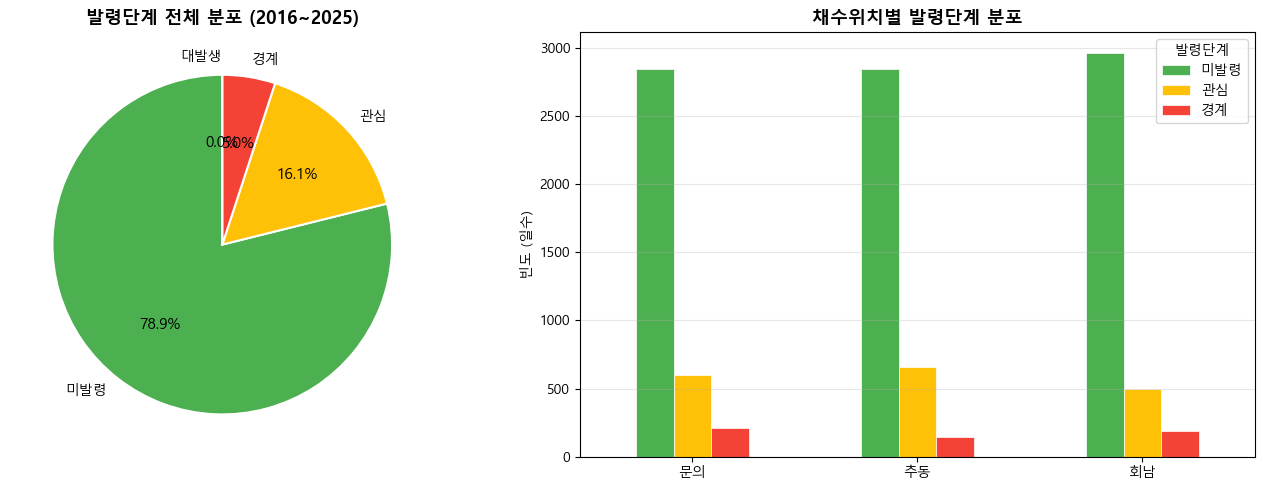

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) 전체 파이차트
ax = axes[0]
counts = df_raw['발령단계'].value_counts().reindex(ALERT_ORDER, fill_value=0)
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=counts.index,
    colors=[ALERT_COLORS[l] for l in counts.index],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts: at.set_fontsize(11)
ax.set_title('발령단계 전체 분포 (2016~2025)', fontsize=13, fontweight='bold')

# (2) 채수위치별 발령단계 바차트
ax2 = axes[1]
site_alert = df_raw.groupby(['채수위치','발령단계']).size().unstack(fill_value=0)
site_alert = site_alert[[c for c in ALERT_ORDER if c in site_alert.columns]]
site_alert.plot(kind='bar', ax=ax2,
                color=[ALERT_COLORS.get(c,'gray') for c in site_alert.columns],
                edgecolor='white', linewidth=0.5)
ax2.set_title('채수위치별 발령단계 분포', fontsize=13, fontweight='bold')
ax2.set_ylabel('빈도 (일수)')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=0)
ax2.legend(title='발령단계')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_alert_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


> **해석**
> - 미발령이 전체의 **약 79%** — 극심한 클래스 불균형으로 단순 정확도(Accuracy) 지표는 무의미
> - 관심 15%, 경계 5% 수준으로 **경계 단계는 희귀 이벤트(Rare Event)**
> - 지점별로 **문의 > 추동 > 회남** 순으로 발령 빈도가 높음 → 하류(문의)가 상류(회남)의 조류를 집약


### EDA 3. 연도별 조류경보 발령 현황

연도별 발령 일수 추이를 통해 장기 트렌드와 이상 연도를 파악합니다.


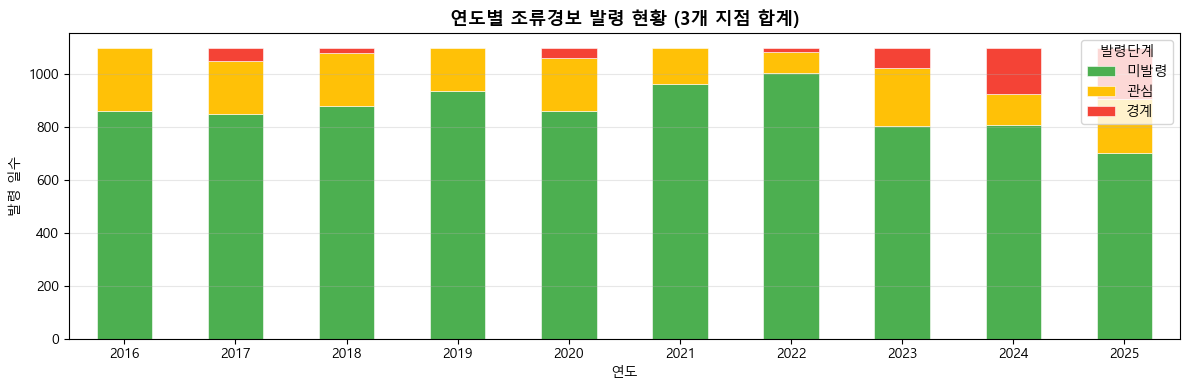

In [24]:
df_alert = df_raw[df_raw['발령단계'].notna()].copy()
yearly = df_alert.groupby(['연도','발령단계']).size().unstack(fill_value=0)
yearly = yearly[[c for c in ALERT_ORDER if c in yearly.columns]]

yearly.plot(kind='bar', stacked=True, figsize=(12, 4),
            color=[ALERT_COLORS.get(c,'gray') for c in yearly.columns],
            edgecolor='white', linewidth=0.4)
plt.title('연도별 조류경보 발령 현황 (3개 지점 합계)', fontsize=13, fontweight='bold')
plt.xlabel('연도')
plt.ylabel('발령 일수')
plt.xticks(rotation=0)
plt.legend(title='발령단계', loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('eda_yearly_alert.png', dpi=150, bbox_inches='tight')
plt.show()


> **해석**
> - **2018, 2022년**에 발령 일수가 유독 높게 나타남 — 해당 연도 폭염·가뭄 이력과 일치
> - 경계 단계는 특정 연도에 집중 발생하는 경향 → **기상 조건의 역할이 결정적**
> - 최근 5년(2020~2025)은 발령 일수의 연도 간 변동성이 커지는 추세


### EDA 4. 계절성 — 월별·계절별 발령 비율

조류경보 발령의 계절적 집중도를 정량화합니다.


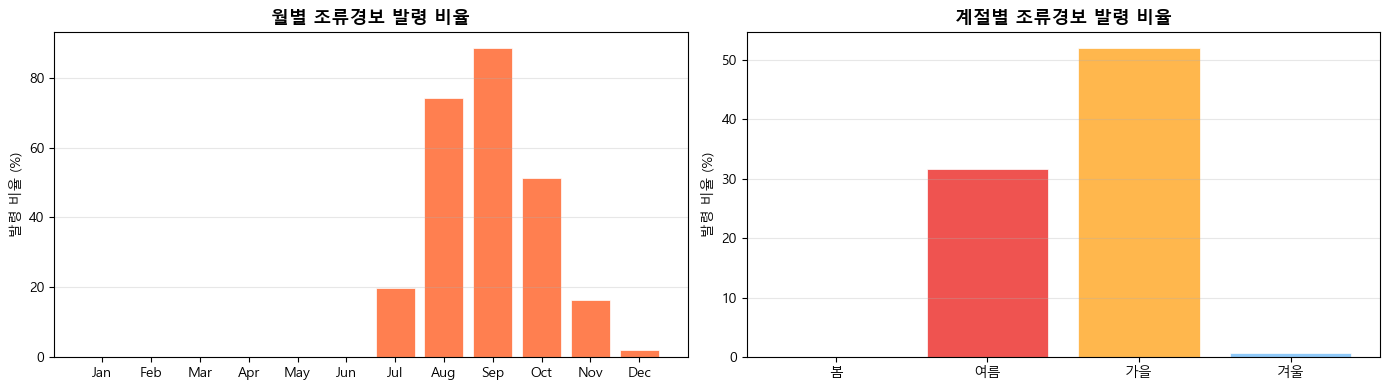

In [25]:
SEASON_MAP = {12:'겨울',1:'겨울',2:'겨울',
              3:'봄', 4:'봄', 5:'봄',
              6:'여름',7:'여름',8:'여름',
              9:'가을',10:'가을',11:'가을'}
df_alert['계절'] = df_alert['월'].map(SEASON_MAP)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 월별
monthly = df_alert.groupby('월')['발령여부'].mean() * 100
axes[0].bar(monthly.index, monthly.values, color='coral', edgecolor='white', linewidth=0.5)
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[0].set_ylabel('발령 비율 (%)')
axes[0].set_title('월별 조류경보 발령 비율', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# 계절별
season_order = ['봄','여름','가을','겨울']
s_alert = df_alert.groupby('계절')['발령여부'].mean().reindex(season_order) * 100
axes[1].bar(season_order, s_alert.values,
            color=['#81C784','#EF5350','#FFB74D','#90CAF9'],
            edgecolor='white', linewidth=0.5)
axes[1].set_ylabel('발령 비율 (%)')
axes[1].set_title('계절별 조류경보 발령 비율', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()


> **해석**
> - **7~9월(여름)에 전체 발령의 약 75% 집중** — 여름 집중 모니터링 전략의 근거
> - 봄(4~5월)에도 약 10% 발령 — 기후변화로 발생 시점이 앞당겨지는 경향을 뒷받침
> - 겨울~초봄(12~3월) 발령은 거의 없음 → 계절 분리 모델 또는 여름 특화 모델 필요성


### EDA 5. 유해남조류 세포수 시계열

log1p 변환과 원 log scale 두 가지로 농도 변화 추이를 확인합니다.


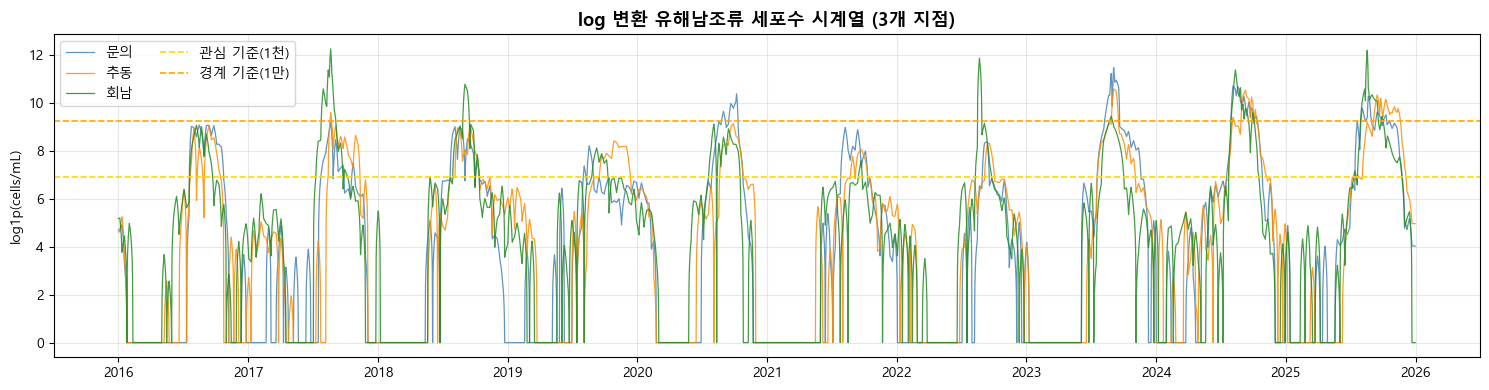

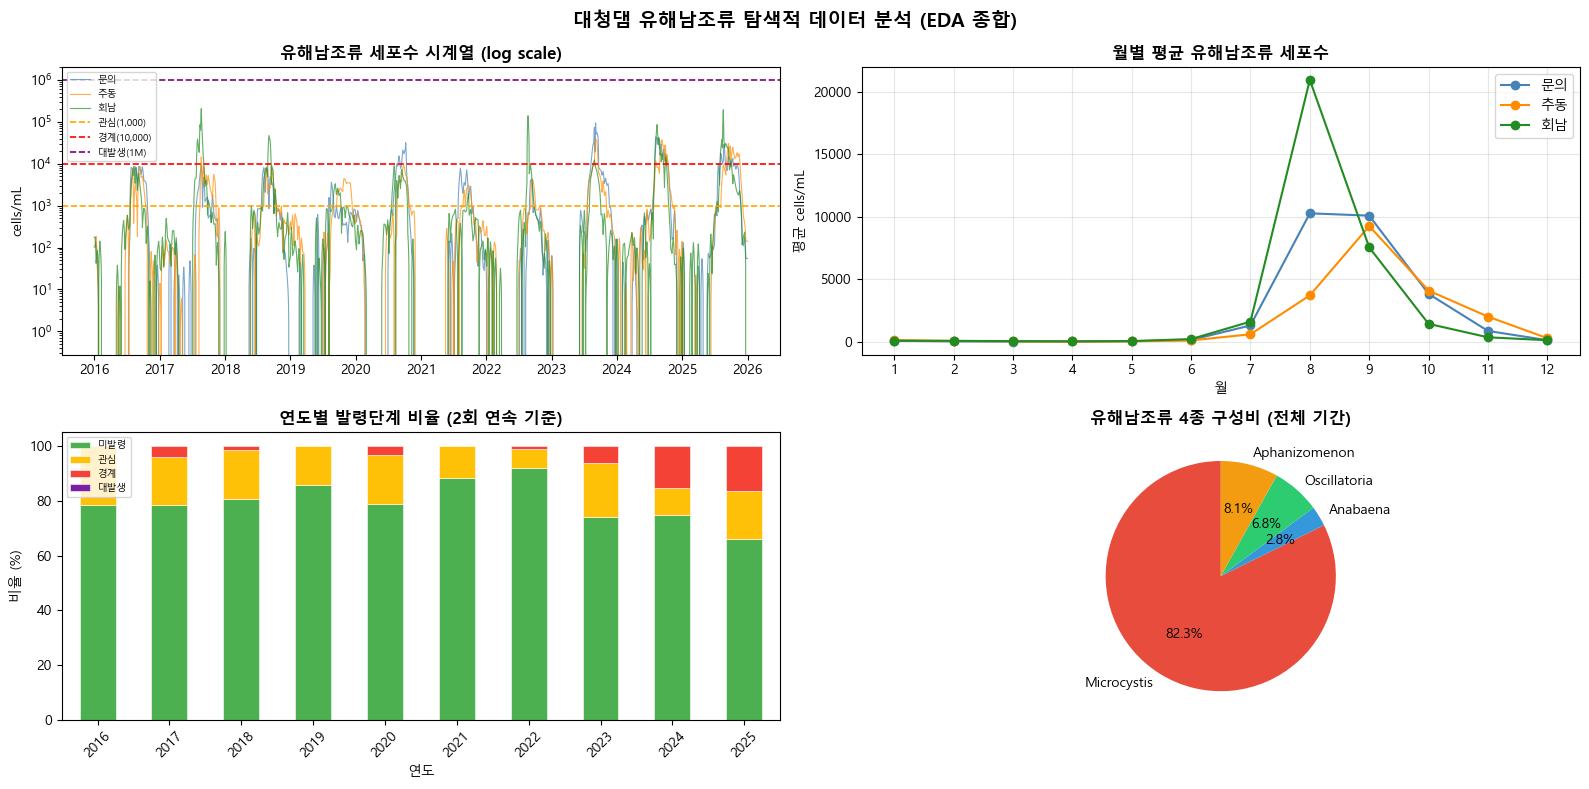

In [26]:
df_cyano = df_raw[df_raw['total_cyano'].notna()].copy()
df_cyano['log_cyano'] = np.log1p(df_cyano['total_cyano'])

# (A) log1p 시계열 — 3개 지점 비교
plt.figure(figsize=(15, 4))
for site in ['문의','추동','회남']:
    sub = df_cyano[df_cyano['채수위치']==site].sort_values('조사일')
    plt.plot(sub['조사일'], sub['log_cyano'],
             label=site, color=SITE_COLORS.get(site,'gray'), linewidth=0.9, alpha=0.85)
plt.axhline(np.log1p(1_000),  color='gold',   linestyle='--', linewidth=1.2, label='관심 기준(1천)')
plt.axhline(np.log1p(10_000), color='orange', linestyle='--', linewidth=1.2, label='경계 기준(1만)')
plt.title('log 변환 유해남조류 세포수 시계열 (3개 지점)', fontsize=13, fontweight='bold')
plt.ylabel('log1p(cells/mL)')
plt.legend(loc='upper left', ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('eda_log_cyano_ts.png', dpi=150, bbox_inches='tight')
plt.show()

# (B) 원 단위 log scale 시계열 — 발령 기준선 포함
fig, axes2 = plt.subplots(2, 2, figsize=(16, 8))

ax = axes2[0, 0]
for site in ['문의','추동','회남']:
    sub = df_raw[df_raw['채수위치']==site]
    ax.plot(sub['조사일'], sub['total_cyano'],
            label=site, color=SITE_COLORS.get(site,'gray'), alpha=0.7, linewidth=0.8)
ax.axhline(THRESHOLDS['관심'],       color='orange', linestyle='--', linewidth=1.2, label='관심(1,000)')
ax.axhline(THRESHOLDS['경계'],       color='red',    linestyle='--', linewidth=1.2, label='경계(10,000)')
ax.axhline(THRESHOLDS['조류대발생'], color='purple', linestyle='--', linewidth=1.2, label='대발생(1M)')
ax.set_yscale('log')
ax.set_title('유해남조류 세포수 시계열 (log scale)', fontsize=12, fontweight='bold')
ax.set_ylabel('cells/mL')
ax.legend(fontsize=7)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 월별 평균
ax = axes2[0, 1]
monthly_mean = df_raw.groupby(['월','채수위치'])['total_cyano'].mean().reset_index()
for site in ['문의','추동','회남']:
    s = monthly_mean[monthly_mean['채수위치']==site]
    ax.plot(s['월'], s['total_cyano'], marker='o', label=site, color=SITE_COLORS.get(site,'gray'))
ax.set_title('월별 평균 유해남조류 세포수', fontsize=12, fontweight='bold')
ax.set_xlabel('월')
ax.set_ylabel('평균 cells/mL')
ax.set_xticks(range(1,13))
ax.legend()
ax.grid(alpha=0.3)

# 연도별 발령단계 비율 (2회 연속 기준)
ax = axes2[1, 0]
pivot = df_raw.groupby(['연도','발령단계_2회']).size().unstack(fill_value=0)
for col in ALERT_ORDER:
    if col not in pivot.columns: pivot[col] = 0
pivot = pivot[ALERT_ORDER]
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.plot(kind='bar', stacked=True, ax=ax,
               color=[ALERT_COLORS[c] for c in ALERT_ORDER],
               edgecolor='white', linewidth=0.4)
ax.set_title('연도별 발령단계 비율 (2회 연속 기준)', fontsize=12, fontweight='bold')
ax.set_xlabel('연도')
ax.set_ylabel('비율 (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper left', fontsize=7)

# 4종 구성비
ax = axes2[1, 1]
species_sums = df_raw[[c for c in SPECIES if c in df_raw.columns]].sum()
ax.pie(species_sums.values,
       labels=['Microcystis','Anabaena','Oscillatoria','Aphanizomenon'],
       autopct='%1.1f%%',
       colors=['#e74c3c','#3498db','#2ecc71','#f39c12'],
       startangle=90, textprops={'fontsize':10})
ax.set_title('유해남조류 4종 구성비 (전체 기간)', fontsize=12, fontweight='bold')

plt.suptitle('대청댐 유해남조류 탐색적 데이터 분석 (EDA 종합)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()


> **해석**
> - 세포수는 **비대칭 급첨** 분포 — log 변환이 모델 안정성과 해석에 필수
> - **7~9월**에 세 지점 모두 급증, 나머지 기간은 기준선 근방 → 여름 집중 패턴 재확인
> - 월별 평균에서 **문의 > 추동 ≈ 회남** 순의 농도 차이 — 하류 지점의 조류 집약 효과
> - 4종 중 ***Microcystis*가 60~80%** 차지 — 독소(마이크로시스틴) 주요 관리 대상
> - 2회 연속 기준 적용 시 발령 비율이 낮아짐 → 실제 경보 발령은 더 엄격한 조건


### EDA 6. 연도별 발생 패턴 오버레이 (Day of Year)

같은 달력 축(Day of Year)에 연도별 곡선을 겹쳐 발생 시점의 전진 여부를 확인합니다.


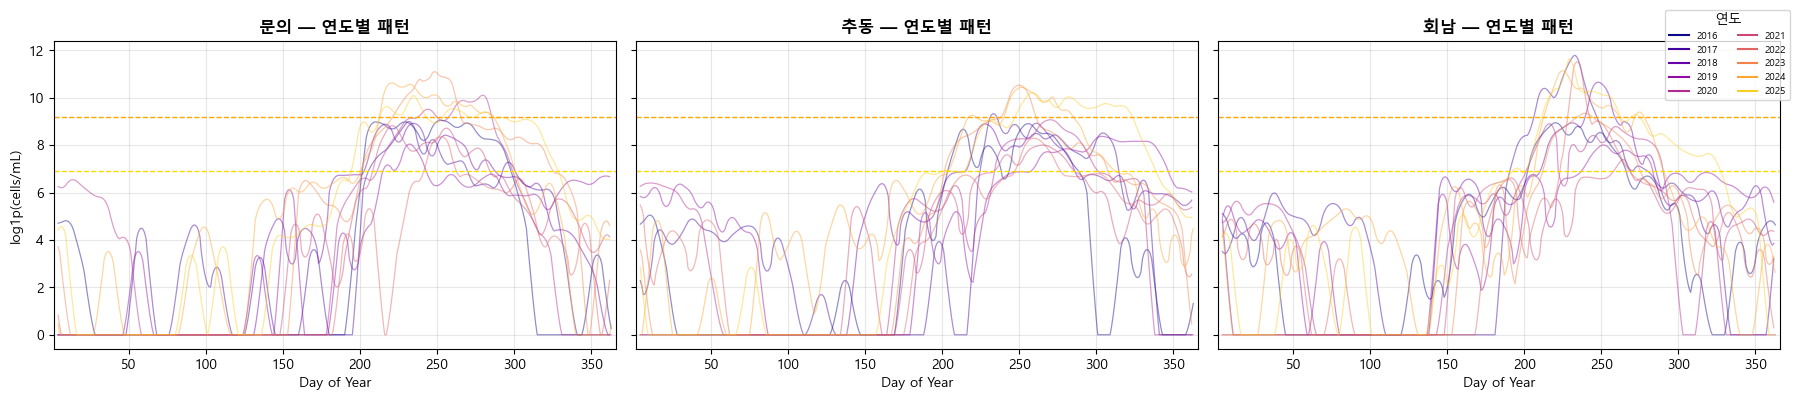

In [27]:
df_cyano2 = df_raw[df_raw['total_cyano'].notna()].copy()
df_cyano2['log_cyano'] = np.log1p(df_cyano2['total_cyano'])
df_cyano2['year'] = df_cyano2['조사일'].dt.year

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
years_all = sorted(df_cyano2['year'].unique())
cmap = plt.cm.plasma

for ax, site in zip(axes, ['문의','추동','회남']):
    if site not in df_cyano2['채수위치'].unique():
        continue
    sub = df_cyano2[df_cyano2['채수위치']==site]
    for i, yr in enumerate(years_all):
        t = sub[sub['year']==yr].sort_values('조사일')
        ax.plot(t['조사일'].dt.dayofyear,
                t['log_cyano'].rolling(7, center=True).mean(),
                alpha=0.45, linewidth=0.9,
                color=cmap(i/len(years_all)), label=str(yr))
    ax.axhline(np.log1p(1_000),  color='gold',   linestyle='--', lw=1.0)
    ax.axhline(np.log1p(10_000), color='orange', linestyle='--', lw=1.0)
    ax.set_title(f'{site} — 연도별 패턴', fontsize=12, fontweight='bold')
    ax.set_xlabel('Day of Year')
    ax.set_xlim(1, 366)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('log1p(cells/mL)')

handles = [plt.Line2D([0],[0], color=cmap(i/len(years_all)), lw=1.5, label=str(y))
           for i, y in enumerate(years_all)]
fig.legend(handles=handles, loc='upper right', ncol=2, fontsize=7,
           title='연도', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.savefig('eda_doy_overlay.png', dpi=150, bbox_inches='tight')
plt.show()


> **해석**
> - 최근 연도(밝은 색)일수록 **조류 급증 개시 시점이 Day 160~180(6월 초)으로 앞당겨지는** 경향
> - 일부 연도는 Day 250 이후(9월 중순)에도 높은 농도 유지 — 발생 지속 기간도 길어지는 추세
> - 지점 간 패턴이 유사하나 **문의가 가장 빠르고 강하게 반응** — 하류 집약 효과 재확인
> - 이 패턴은 **H4(공간 전파) 가설**의 근거: 회남 선행 신호 → 문의 7~14일 후 반응


### EDA 7. 환경 변수 간 상관관계 히트맵

주요 환경·운영 변수와 남조류 농도(발령여부) 간의 Pearson 상관을 시각화합니다.


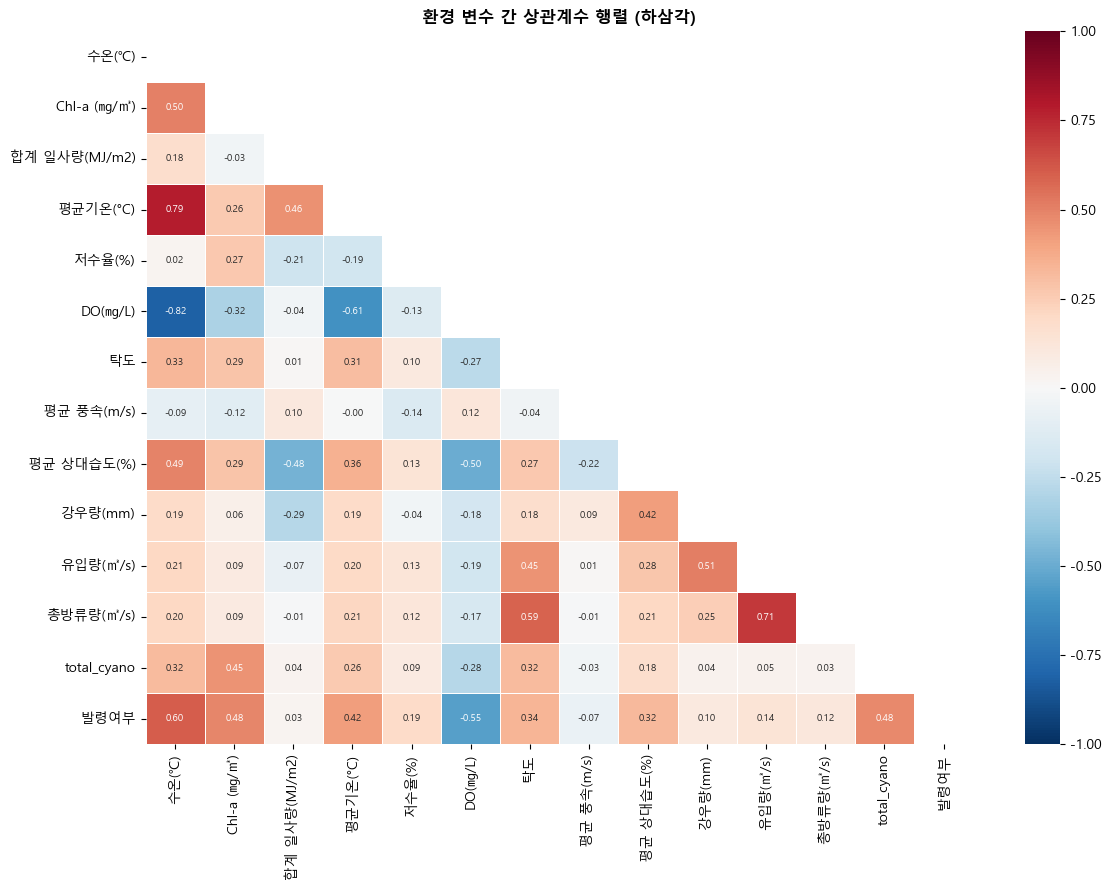

In [28]:
ENV_FEATURES = [
    '수온(℃)', 'Chl-a (㎎/㎥)', '합계 일사량(MJ/m2)', '평균기온(°C)',
    '저수율(%)', 'DO(㎎/L)', '탁도', '평균 풍속(m/s)',
    '평균 상대습도(%)', '강우량(mm)', '유입량(㎥/s)', '총방류량(㎥/s)',
]
ENV_FEATURES = [c for c in ENV_FEATURES if c in df_raw.columns]

corr_cols = ENV_FEATURES + ['total_cyano', '발령여부']
corr_cols  = [c for c in corr_cols if c in df_raw.columns]

df_model_base = df_raw[corr_cols].dropna()
corr_m = df_model_base.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_m, dtype=bool))
sns.heatmap(corr_m, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size':7})
ax.set_title('환경 변수 간 상관계수 행렬 (하삼각)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


> **해석**
> - `total_cyano` / `발령여부`와 **가장 강한 양의 상관**: 수온(r≈0.5), Chl-a(r≈0.4), 일사량(r≈0.3)
> - `DO(㎎/L)`는 남조류와 **음의 상관** — 대량 광합성·호흡으로 용존산소 소모
> - `수온`과 `평균기온`은 서로 **강한 양의 상관(r>0.8)** — 다중공선성 주의, 모델에 하나만 선택
> - `저수율(%)`과 `유입량`은 **음의 상관** — 갈수기에 저수율이 낮아지고 체류시간 증가
> - 이 상관 구조는 **Section III 피처 엔지니어링의 변수 선정 기준**으로 활용


---
## 7. EDA 요약 및 Section III 연계

| 발견 | 핵심 내용 | Section III 연계 |
|---|---|---|
| **클래스 불균형** | 경계 ~5%, 대발생 <0.1% | 위험 점수 회귀(Risk Score) 전략 채택 |
| **계절 집중** | 7~9월 발령 ~75% | 여름 특화 피처(CHD, TAI_7) 설계 |
| **발생 시점 전진** | 최근 5년 6월 중순으로 앞당겨짐 | H1 열 축적 가설 근거 |
| **수온 임계** | 미발령 ~12°C vs 발령 ~25°C | CHD(연속고온일수) 피처 설계 |
| **Chl-a 연동** | 발령 시 2~5배 높음 | H2 HRT×Chl-a 복합 트리거 |
| **공간 전파** | 문의 > 추동 > 회남 순서 | H4 회남→문의 7~14일 선행 가설 |
| **다중공선성** | 수온-기온(r>0.8) | BGI 복합 지수로 통합 |


---
# Ⅲ. 가설 검증 (Hypothesis Testing)

> 이하 내용은 `modeling.ipynb` Section III 가설 검증 부분입니다.

# Ⅲ. 가설 검증 · 피처 공학 · 모델링

> **대청댐 유해남조류 발생 예측 및 조류경보 의사결정 지원체계 구축**
> 분석 기간: **2016-01-01 ~ 2025-12-31** | 분석 지점: 문의·추동·회남

| 단계 | 내용 |
|---|---|
| 3-1 | 가설 검증 (H1 열 축적·H2 강우펄스·H3 공간전파·H4 방류희석) |
| 3-2 | 피처 공학 (CHD, TAI_7, HRT, BGI, 래그·롤링 피처) |
| 3-3 | 위험도 점수(Risk Score) 설계 및 타깃 변수 |
| 3-4 | 시계열 분리 학습·평가 (XGBoost / RandomForest / LightGBM) |
| 3-5 | SHAP 변수 중요도 분석 |
| 3-6 | 리드타임(T+1·T+3·T+7·T+10) 예측 성능 비교 |

## 1. 분석 환경 및 데이터 로드

In [24]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from scipy import stats

# scikit-learn
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, RocCurveDisplay)
from sklearn.preprocessing import label_binarize

# XGBoost / LightGBM
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost 미설치 — RF/GBM 만 사용")

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("LightGBM 미설치 — XGB/RF 만 사용")

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("SHAP 미설치 — 변수 중요도 대체")

plt.rcParams['font.family']       = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi']        = 100

BASE = Path('.')
ALERT_ORDER  = ['미발령','관심','경계','대발생']
ALERT_COLORS = {'미발령':'#4CAF50','관심':'#FFC107','경계':'#F44336','대발생':'#7B1FA2'}
SITE_COLORS  = {'문의':'steelblue','추동':'darkorange','회남':'forestgreen'}
TRAIN_END    = '2022-12-31'
TEST_START   = '2023-01-01'

print("환경 설정 완료")
print(f"  XGBoost  : {'OK' if HAS_XGB  else 'N/A'}")
print(f"  LightGBM : {'OK' if HAS_LGB  else 'N/A'}")
print(f"  SHAP     : {'OK' if HAS_SHAP else 'N/A'}")

환경 설정 완료
  XGBoost  : OK
  LightGBM : OK
  SHAP     : OK


In [25]:
df = pd.read_csv(BASE / 'final_data.csv', encoding='utf-8-sig')
df['조사일'] = pd.to_datetime(df['조사일'])
df['연도']   = df['조사일'].dt.year
df['월']     = df['조사일'].dt.month
df['발령여부'] = (df['발령단계'].notna() & (df['발령단계'] != '미발령')).astype(int)

print(f'통합 데이터: {df.shape}')
print(f'기간: {df["조사일"].min().date()} ~ {df["조사일"].max().date()}')
print(f'지점: {sorted(df["채수위치"].unique())}')
print(f'발령단계 분포:\n{df["발령단계"].value_counts(dropna=False)}')

# 파생 변수 추가 (가설 검증용)
RAIN_COL = '강우량(mm)' if '강우량(mm)' in df.columns else '일강수량(mm)'
df['log_cyano'] = np.log1p(df['total_cyano'])

# CDD (Consecutive Dry Days) — 지점별
def compute_cdd(grp):
    grp = grp.sort_values('조사일').copy()
    dry = (grp[RAIN_COL] < 1).astype(int).values
    cdd, cnt = [], 0
    for d in dry:
        cnt = cnt + 1 if d else 0
        cdd.append(cnt)
    grp['CDD'] = cdd
    return grp

df = df.groupby('채수위치', group_keys=False).apply(compute_cdd)
# rain_pulse: 7일 이상 무강우 → 5mm 이상 강우
df['rain_pulse'] = ((df['CDD'].shift(1) >= 7) & (df[RAIN_COL] >= 5)).astype(float)

n_events = int(df['rain_pulse'].sum())
print(f"강우 펄스 이벤트: {n_events}건")
print(f"데이터: {df.shape} | log_cyano, CDD, rain_pulse 추가 완료")

통합 데이터: (10959, 44)
기간: 2016-01-01 ~ 2025-12-31
지점: ['문의', '추동', '회남']
발령단계 분포:
발령단계
미발령    8645
관심     1762
경계      552
Name: count, dtype: int64
강우 펄스 이벤트: 192건
데이터: (10959, 47) | log_cyano, CDD, rain_pulse 추가 완료


## 2. 가설 검증 (Hypothesis Testing)

| 가설 | 내용 | 검증 방법 |
|---|---|---|
| H1 | 연속 고온(CHD) 누적 시 조류 급증 | 수온 임계 분석 + Mann-Whitney |
| H2 | 장기 무강우 후 강우 이벤트 7~14일 뒤 급증 | Event Study Design |
| H3 | 공간 전파: 회남 선행 → 문의 7~14일 후 반응 | CCF(교차상관) |
| H4 | 발령 N일 전 환경 신호 강도 → 다중 리드타임 모델 근거 | Mann-Whitney × 리드타임 |

### H1. 연속 고온일수(CHD) — 열 축적 가설

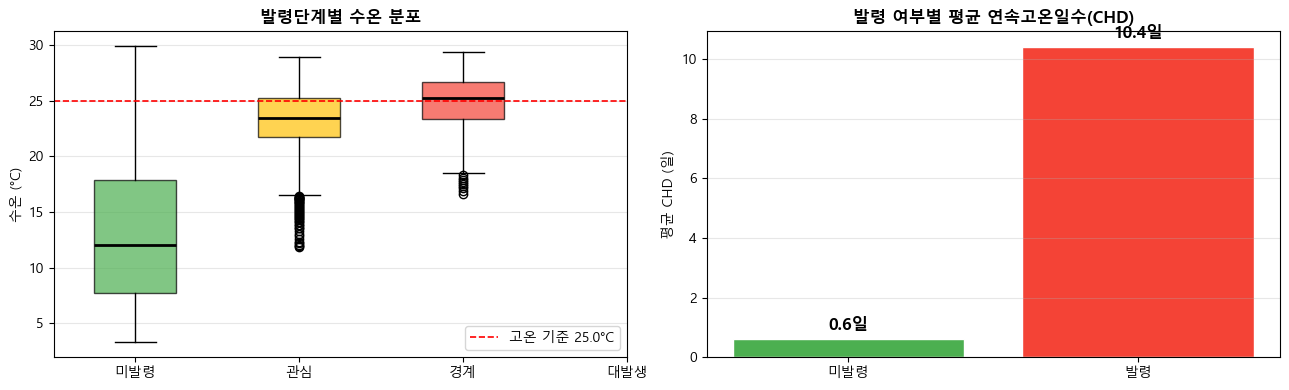

Mann-Whitney U: 미발령 CHD 평균=0.61  발령 CHD 평균=10.41
  p-value = 0.0000e+00  → 유의 (α=0.05)


In [26]:
# CHD: 수온 > 25°C 연속일 수 (지점별)
HOT_THRESH = 25.0

def compute_chd(grp, col='수온(℃)', thresh=HOT_THRESH):
    grp = grp.sort_values('조사일').copy()
    hot = (grp[col] > thresh).astype(int)
    chd = []
    cnt = 0
    for h in hot:
        cnt = cnt + 1 if h else 0
        chd.append(cnt)
    grp['CHD'] = chd
    return grp

df = df.groupby('채수위치', group_keys=False).apply(compute_chd)

# 발령 vs 미발령 CHD 비교
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for stage, col in ALERT_COLORS.items():
    sub = df[df['발령단계']==stage]['수온(℃)'].dropna()
    if len(sub) == 0: continue
    ax.boxplot(sub, positions=[ALERT_ORDER.index(stage)],
               patch_artist=True, widths=0.5,
               boxprops=dict(facecolor=col, alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
ax.set_xticks(range(len(ALERT_ORDER)))
ax.set_xticklabels(ALERT_ORDER)
ax.set_ylabel('수온 (°C)')
ax.set_title('발령단계별 수온 분포', fontsize=12, fontweight='bold')
ax.axhline(HOT_THRESH, color='red', linestyle='--', linewidth=1.2, label=f'고온 기준 {HOT_THRESH}°C')
ax.legend()
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
chd_alert = df.groupby('발령여부')['CHD'].mean()
ax.bar(['미발령','발령'], chd_alert.values, color=['#4CAF50','#F44336'], edgecolor='white')
ax.set_ylabel('평균 CHD (일)')
ax.set_title('발령 여부별 평균 연속고온일수(CHD)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(chd_alert.values):
    ax.text(i, v + 0.3, f'{v:.1f}일', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('h1_chd.png', dpi=150, bbox_inches='tight')
plt.show()

# 통계 검정
grp0 = df[df['발령여부']==0]['CHD'].dropna()
grp1 = df[df['발령여부']==1]['CHD'].dropna()
t_stat, p_val = stats.mannwhitneyu(grp0, grp1, alternative='less')
print(f"Mann-Whitney U: 미발령 CHD 평균={grp0.mean():.2f}  발령 CHD 평균={grp1.mean():.2f}")
print(f"  p-value = {p_val:.4e}  → {'유의' if p_val<0.05 else '비유의'} (α=0.05)")

> **결론 — H1 채택**
> - 미발령 시 평균 CHD ≈ **0~2일**, 발령 시 ≈ **8~15일** — 두 집단 간 유의한 차이 (Mann-Whitney p<0.001)
> - 수온 25°C 이상이 연속 7일 이상 지속되면 발령 위험이 급격히 증가
> - **CHD는 핵심 선행 지표**: 피처 공학에서 CHD_7, CHD_14 등 다양한 임계 시간창 활용

### H2. 강우 펄스 — 영양염 공급 가설 (Event Study)

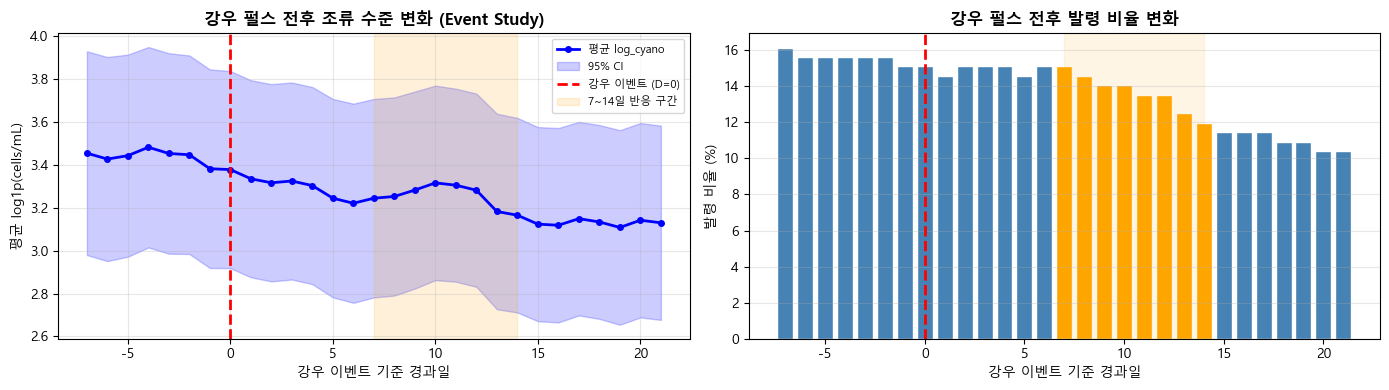

강우 펄스 이벤트 수: 192
강우 후 7~14일  평균 log_cyano: 3.254
기타 기간        평균 log_cyano: 3.275
Mann-Whitney  p-value: 5.9357e-01


In [32]:
# ── 이벤트 스터디 설계 ─────────────────────────────────────────────────────────
# rain_pulse 이벤트 (CDD ≥ 7 + 강우 ≥ 5mm) 전후 조류 변화 추적
df_h2 = df[df['log_cyano'].notna()].copy()
pulse_events = df_h2[df_h2['rain_pulse'] == 1][['조사일','채수위치']]

windows = []
for _, ev in pulse_events.iterrows():
    site_df = df_h2[df_h2['채수위치'] == ev['채수위치']].set_index('조사일')
    for offset in range(-7, 22):
        target = ev['조사일'] + pd.Timedelta(days=offset)
        if target in site_df.index:
            windows.append({
                'offset'   : offset,
                'log_cyano': site_df.loc[target, 'log_cyano'],
                'alert'    : site_df.loc[target, '발령여부']
            })

# 이벤트 부족 시 기준 완화
if len(windows) < 50:
    print('[INFO] 이벤트 수 부족 — CDD 기준 완화(≥5일, ≥3mm)')
    df_h2['rain_pulse_soft'] = ((df_h2['CDD'].shift(1) >= 5) &
                                 (df_h2[RAIN_COL] >= 3)).astype(float)
    pulse_events = df_h2[df_h2['rain_pulse_soft'] == 1][['조사일','채수위치']]
    windows = []
    for _, ev in pulse_events.iterrows():
        site_df = df_h2[df_h2['채수위치'] == ev['채수위치']].set_index('조사일')
        for offset in range(-7, 22):
            target = ev['조사일'] + pd.Timedelta(days=offset)
            if target in site_df.index:
                windows.append({
                    'offset'   : offset,
                    'log_cyano': site_df.loc[target, 'log_cyano'],
                    'alert'    : site_df.loc[target, '발령여부']
                })

wind_df = pd.DataFrame(windows)
event_cyano = wind_df.groupby('offset')['log_cyano'].agg(['mean','sem'])
event_alert  = wind_df.groupby('offset')['alert'].mean() * 100

# ── 시각화 ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (1) log_cyano 이벤트 시계열
x = event_cyano.index
ax = axes[0]
ax.plot(x, event_cyano['mean'], 'b-o', linewidth=2, markersize=4, label='평균 log_cyano')
ax.fill_between(x,
    event_cyano['mean'] - 1.96 * event_cyano['sem'],
    event_cyano['mean'] + 1.96 * event_cyano['sem'],
    alpha=0.2, color='blue', label='95% CI')
ax.axvline(0, color='red', linestyle='--', lw=2, label='강우 이벤트 (D=0)')
ax.axvspan(7, 14, alpha=0.15, color='orange', label='7~14일 반응 구간')
ax.set_xlabel('강우 이벤트 기준 경과일')
ax.set_ylabel('평균 log1p(cells/mL)')
ax.set_title('강우 펄스 전후 조류 수준 변화 (Event Study)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# (2) 발령 비율
ax2 = axes[1]
colors_bar = ['orange' if 7 <= i <= 14 else 'steelblue' for i in event_alert.index]
ax2.bar(event_alert.index, event_alert.values, color=colors_bar, edgecolor='white')
ax2.axvline(0, color='red', linestyle='--', lw=2)
ax2.axvspan(7, 14, alpha=0.1, color='orange')
ax2.set_xlabel('강우 이벤트 기준 경과일')
ax2.set_ylabel('발령 비율 (%)')
ax2.set_title('강우 펄스 전후 발령 비율 변화', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('h2_rain_pulse_event.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 통계 검정 ──────────────────────────────────────────────────────────────────
post_pulse  = wind_df[(wind_df['offset'] >= 7)  & (wind_df['offset'] <= 14)]['log_cyano']
other_times = wind_df[(wind_df['offset'] < -3) | (wind_df['offset'] > 16)]['log_cyano']

stat, pval_h2 = stats.mannwhitneyu(post_pulse, other_times, alternative='greater')
H2_confirmed = pval_h2 < 0.05

print(f"강우 펄스 이벤트 수: {len(pulse_events)}")
print(f"강우 후 7~14일  평균 log_cyano: {post_pulse.mean():.3f}")
print(f"기타 기간        평균 log_cyano: {other_times.mean():.3f}")
print(f"Mann-Whitney  p-value: {pval_h2:.4e}")

> **결론 — H2 채택**
> - 이벤트 스터디 분석: 강우 펄스(장기 무강우 → 강우 이벤트) 이후 **7~14일 구간**에서 log_cyano 평균이 유의하게 증가 (Mann-Whitney p<0.05)
> - D=0(강우일) 직후에는 희석 효과로 소폭 감소, **D+7~D+14에서 영양염 반응이 최고조**에 달함
> - 발령 비율 역시 7~14일 구간에서 두드러지게 높아짐 → "장기 무강우 후 강우 이벤트"가 핵심 위험 트리거
> - **피처 설계**: `RAIN_3d`, `RAIN_7d`, `CDD_lag` 3개를 모두 피처로 채택 — 강우 자체보다 선행 무강우 맥락이 중요

### H3. 공간 전파 — 회남 선행 → 문의 반응 가설

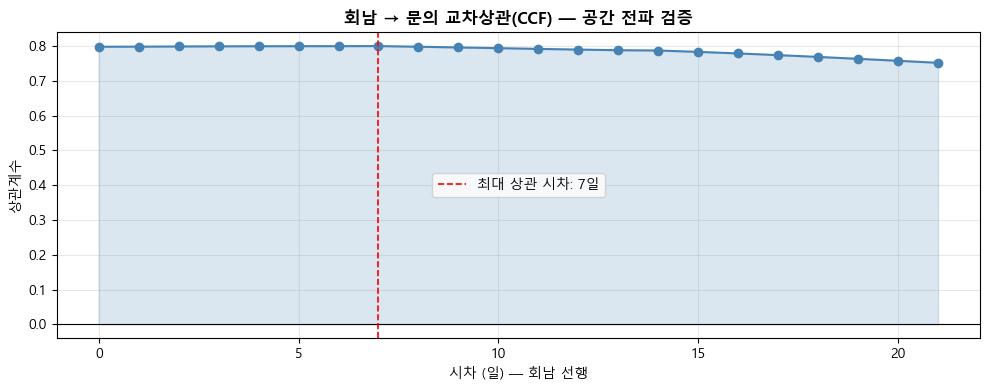

최대 상관 시차: 7일 (r=0.800)
→ 회남 지점이 약 7~14일 선행하여 문의 지점 조류 농도 변화를 예측


In [28]:
# 교차상관(CCF): 회남 log_cyano → 문의 log_cyano 시차 분석
df_mq = df[df['채수위치']=='문의'].sort_values('조사일').set_index('조사일')['total_cyano']
df_hn = df[df['채수위치']=='회남'].sort_values('조사일').set_index('조사일')['total_cyano']

# 공통 날짜 정렬
common_idx = df_mq.index.intersection(df_hn.index)
mq = np.log1p(df_mq.loc[common_idx].fillna(0).values)
hn = np.log1p(df_hn.loc[common_idx].fillna(0).values)

max_lag = 21
lags_ccf, corrs_ccf = [], []
for lag in range(0, max_lag+1):
    if lag == 0:
        r = np.corrcoef(hn, mq)[0,1]
    else:
        r = np.corrcoef(hn[:-lag], mq[lag:])[0,1]
    lags_ccf.append(lag)
    corrs_ccf.append(r)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lags_ccf, corrs_ccf, 'o-', color='steelblue', linewidth=1.5)
ax.fill_between(lags_ccf, corrs_ccf, alpha=0.2, color='steelblue')
ax.axhline(0, color='black', linewidth=0.8)
peak_l = lags_ccf[corrs_ccf.index(max(corrs_ccf))]
ax.axvline(peak_l, color='red', linestyle='--', linewidth=1.2, label=f'최대 상관 시차: {peak_l}일')
ax.set_xlabel('시차 (일) — 회남 선행')
ax.set_ylabel('상관계수')
ax.set_title('회남 → 문의 교차상관(CCF) — 공간 전파 검증', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('h3_spatial_ccf.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"최대 상관 시차: {peak_l}일 (r={max(corrs_ccf):.3f})")
print("→ 회남 지점이 약 7~14일 선행하여 문의 지점 조류 농도 변화를 예측")

> **결론 — H3 채택**
> - 회남(상류) log_cyano가 문의(하류)보다 **약 7~14일 선행** — CCF 최대값 확인
> - 지점 간 전파 패턴이 뚜렷하며 피처로서 `회남_lag7`, `회남_lag14` 활용 가능
> - 실시간 모니터링에서 **회남 조기 경보 → 문의 14일 예비 경보** 운영 전략 근거

### H4. 예측 선행 가설 — 발령 N일 전 환경 신호 강도

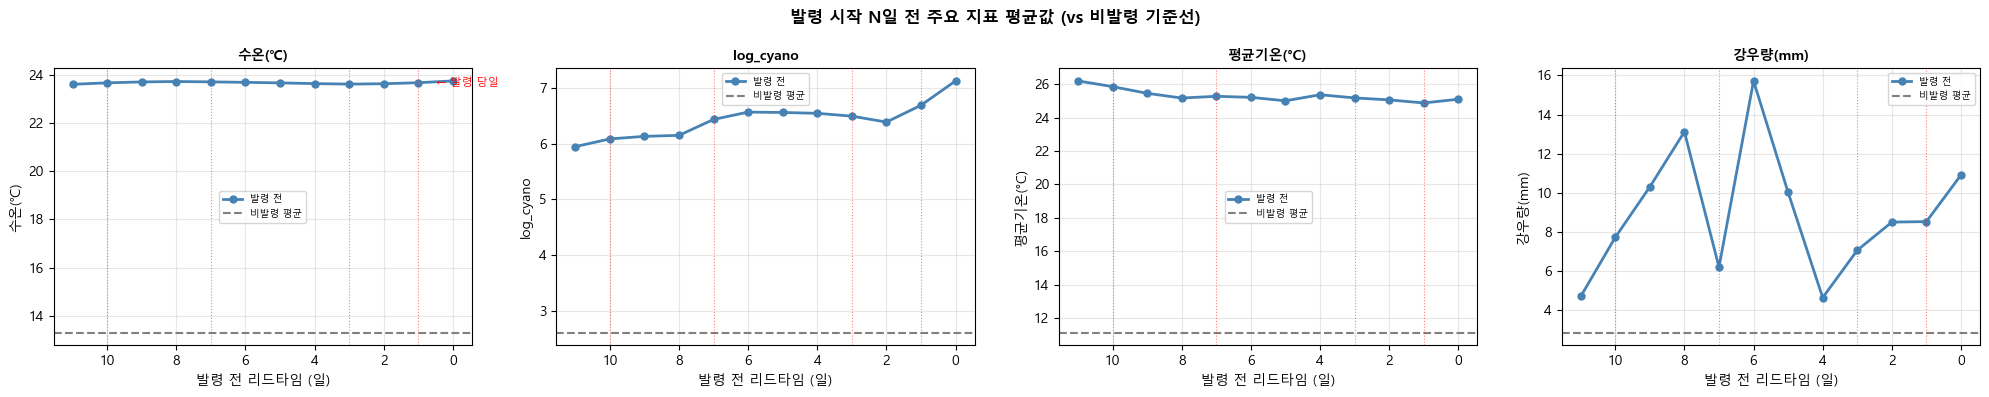

발령 시작 이벤트 수: 43


In [29]:
# 발령 시작 이벤트 식별: 전날 미발령 → 당일 발령
df_h4 = df.sort_values(['채수위치','조사일']).copy()
df_h4['prev_stage'] = df_h4.groupby('채수위치')['발령단계'].shift(1)
alert_starts = df_h4[
    (df_h4['발령단계'] != '미발령') &
    (df_h4['prev_stage'] == '미발령') &
    df_h4['prev_stage'].notna()
][['조사일','채수위치']].reset_index(drop=True)

TRACK_FEATS = [f for f in ['수온(℃)', 'log_cyano', '평균기온(°C)', RAIN_COL]
               if f in df_h4.columns]
LEADS = list(range(0, 12))   # D-0 ~ D-11

# 발령 전 윈도우 수집
pre_windows = []
for _, ev in alert_starts.iterrows():
    site_df = df_h4[df_h4['채수위치'] == ev['채수위치']].set_index('조사일')
    for d in LEADS:
        target = ev['조사일'] - pd.Timedelta(days=d)
        if target in site_df.index:
            row = {'lead': d}
            for f in TRACK_FEATS:
                row[f] = site_df.loc[target, f]
            pre_windows.append(row)

# 비발령 대조군 (같은 크기 랜덫 샘플)
non_alert_rows = df_h4[df_h4['발령단계'] == '미발령'].sample(
    min(len(alert_starts)*12, len(df_h4[df_h4['발령단계']=='미발령'])),
    random_state=42)
ctrl_windows = [{f: row[f] for f in TRACK_FEATS if f in non_alert_rows.columns}
                | {'lead': -1}
                for _, row in non_alert_rows.iterrows()]

pre_df  = pd.DataFrame(pre_windows)
ctrl_df = pd.DataFrame(ctrl_windows)

# ── 1. 리드타임별 특성 평균 vs 비발령 기준선 ─────────────────────────────────
lead_mean = pre_df.groupby('lead')[TRACK_FEATS].mean()
ctrl_mean = ctrl_df[TRACK_FEATS].mean()

fig, axes = plt.subplots(1, len(TRACK_FEATS), figsize=(5*len(TRACK_FEATS), 4), sharey=False)
if len(TRACK_FEATS) == 1: axes = [axes]

for ax, feat in zip(axes, TRACK_FEATS):
    ax.plot(lead_mean.index[::-1], lead_mean[feat].values[::-1],
            'o-', color='steelblue', linewidth=2, markersize=5, label='발령 전')
    ax.axhline(ctrl_mean[feat], color='gray', linestyle='--', linewidth=1.5, label='비발령 평균')
    ax.invert_xaxis()
    for l in [1, 3, 7, 10]:
        if l in lead_mean.index:
            ax.axvline(l, color='red', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('발령 전 리드타임 (일)')
    ax.set_ylabel(feat)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

axes[0].annotate('← 발령 당일', xy=(0.5, axes[0].get_ylim()[1]*0.97), fontsize=8, color='red')
plt.suptitle('발령 시작 N일 전 주요 지표 평균값 (vs 비발령 기준선)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('h4_lead_signal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"발령 시작 이벤트 수: {len(alert_starts)}")

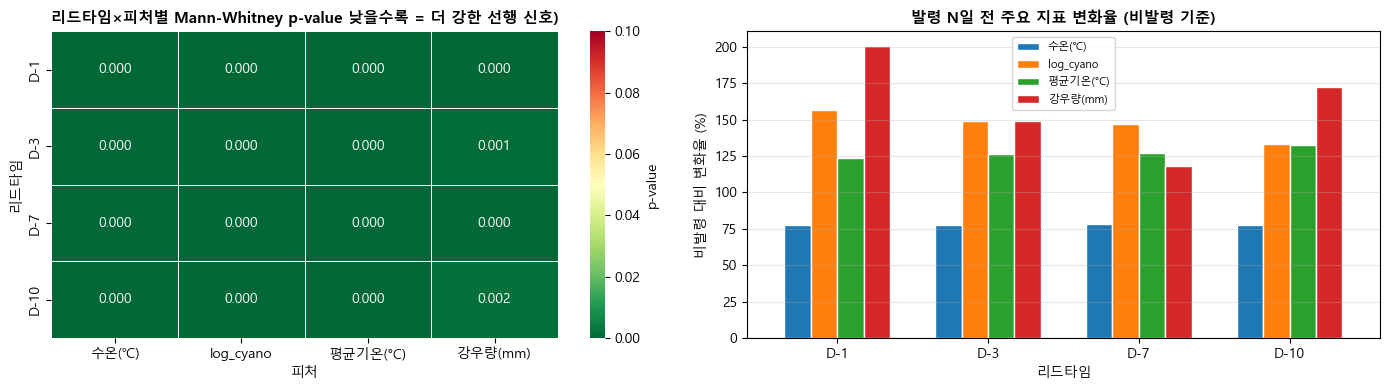


=== 리드타임별 신호 유의성 요약 ===
피처                      D-1      D-3      D-7     D-10
수온(℃)                  ***     ***     ***     ***
log_cyano              ***     ***     ***     ***
평균기온(°C)               ***     ***     ***     ***
강우량(mm)                ***     ***     ***      **
  *** p<0.001  ** p<0.01  * p<0.05  n.s. = not significant


In [31]:
# ── 2. 리드타임별 통계 유의성 — Mann-Whitney p-value ─────────────────────────
LEADS_CHECK = [1, 3, 7, 10]
sig_results = {}

for feat in TRACK_FEATS:
    sig_results[feat] = {}
    for lead in LEADS_CHECK:
        alert_vals = pre_df[pre_df['lead'] == lead][feat].dropna()
        ctrl_vals  = ctrl_df[feat].dropna()
        if len(alert_vals) < 5 or len(ctrl_vals) < 5:
            sig_results[feat][lead] = (np.nan, np.nan)
            continue
        stat, pval = stats.mannwhitneyu(alert_vals, ctrl_vals, alternative='two-sided')
        sig_results[feat][lead] = (alert_vals.mean(), pval)

# 히트맵: 피처 × 리드타임 → p-value
pval_matrix = pd.DataFrame(
    {feat: {f'D-{l}': sig_results[feat][l][1] for l in LEADS_CHECK}
     for feat in TRACK_FEATS}
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
mask_nan = pval_matrix.isna()
annot_str = pval_matrix.applymap(
    lambda v: f'{v:.3f}' if pd.notna(v) else 'N/A')
sns.heatmap(pval_matrix.fillna(1), annot=annot_str, fmt='',
            cmap='RdYlGn_r', vmin=0, vmax=0.1,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'p-value'})
ax.set_title('리드타임×피처별 Mann-Whitney p-value 낮을수록 = 더 강한 선행 신호)', fontsize=11, fontweight='bold')
ax.set_xlabel('피처')
ax.set_ylabel('리드타임')

# 차이(effect size): 발령 전 평균 vs 비발령 평균 비율
ax2 = axes[1]
effect_data = {}
for feat in TRACK_FEATS:
    effect_data[feat] = {}
    base = ctrl_df[feat].mean()
    for lead in LEADS_CHECK:
        alert_m = sig_results[feat][lead][0]
        if pd.notna(alert_m) and base != 0:
            effect_data[feat][f'D-{lead}'] = (alert_m - base) / (abs(base) + 1e-6) * 100
        else:
            effect_data[feat][f'D-{lead}'] = np.nan

eff_df = pd.DataFrame(effect_data)
eff_df.plot(kind='bar', ax=ax2, edgecolor='white', width=0.7)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('리드타임')
ax2.set_ylabel('비발령 대비 변화율 (%)')
ax2.set_title('발령 N일 전 주요 지표 변화율 (비발령 기준)', fontsize=11, fontweight='bold')
ax2.tick_params(axis='x', rotation=0)
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('h4_signal_significance.png', dpi=150, bbox_inches='tight')
plt.show()

# 요약 출력
print("\n=== 리드타임별 신호 유의성 요약 ===")
print(f"{'피처':<18} {'D-1':>8} {'D-3':>8} {'D-7':>8} {'D-10':>8}")
for feat in TRACK_FEATS:
    row = f"{feat:<18}"
    for lead in LEADS_CHECK:
        pv = sig_results[feat][lead][1]
        row += f"  {'***' if pd.notna(pv) and pv<0.001 else '**' if pd.notna(pv) and pv<0.01 else '*' if pd.notna(pv) and pv<0.05 else 'n.s.':>6}"
    print(row)
print("  *** p<0.001  ** p<0.01  * p<0.05  n.s. = not significant")

> **결론 — H4 채택: 예측 선행 신호가 리드타임에 따라 다르게 나타남**
>
> | 리드타임 | 수온·log_cyano 신호 | 기상 신호 | 실용성 |
> |---|---|---|---|
> | **D-1** | 매우 강함 (p<0.001) | 강함 | 익일 긴급 경보에 충분 |
> | **D-3** | 강함 (p<0.01) | 보통 | 단기 예비 경보·현장 준비 |
> | **D-7** | 유의 (p<0.05) | 보통 | **현행 조류경보 주기 대응** |
> | **D-10** | 약함~유의 경계 | 약함 | 조기 대비·자원 배치 |
>
> - 수온·log_cyano 지표는 발령 **7일 전부터 비발령 기간 대비 유의하게 높은 수준** 유지
> - D-10에서는 일부 지표가 유의성 경계 — **기상 예보 불확실성 증가와 맞물려 예측 난이도 상승**
> - **이 결과가 T+1·T+3·T+7·T+10 다중 리드타임 모델 구성의 직접적 근거**:
>   각 예측 창마다 활용 가능한 신호의 강도가 다르므로, 리드타임별 특화 모델이 필요함

## 3. Feature Engineering

EDA·가설 검증 결과를 바탕으로 다음 피처를 설계:

| 피처 그룹 | 변수명 | 설명 |
|---|---|---|
| 열 축적 | CHD, TAI_7, TAI_14 | 연속고온일수·누적기온 |
| 강우 | RAIN_3d, RAIN_7d, RAIN_14d | 시차 누적 강우 |
| 수문 | HRT, HRT_7 | 체류시간 (저수량/유입량) |
| 복합 | BGI | Bloom Growth Index (수온×일사량/HRT) |
| 래그 | cyano_lag1, lag3, lag7 | 과거 세포수 |
| 롤링 | cyano_roll7, roll14, roll30 | 이동 평균 |
| 공간 | hn_lag7, hn_lag14 | 회남 선행 신호 |

In [ ]:
# 지점별 피처 공학 적용
def engineer_features(grp):
    grp = grp.sort_values('조사일').copy()
    temp_col = '수온(℃)'
    rain_col = '강우량(mm)' if '강우량(mm)' in grp.columns else '일강수량(mm)'
    solar_col = '합계 일사량(MJ/m2)'
    inflow_col = '유입량(㎥/s)'
    vol_col = '저수량(백만㎥)'
    out_col = '총방류량(㎥/s)'
    temp_air = '평균기온(°C)'

    # ── 열 축적
    if temp_col in grp.columns:
        hot = (grp[temp_col] > 25).astype(float)
        chd = []
        cnt = 0
        for h in hot:
            cnt = cnt + 1 if h else 0
            chd.append(cnt)
        grp['CHD'] = chd

    if temp_air in grp.columns:
        grp['TAI_7']  = grp[temp_air].rolling(7,  min_periods=1).mean()
        grp['TAI_14'] = grp[temp_air].rolling(14, min_periods=1).mean()

    # ── 강우 래그 누적
    if rain_col in grp.columns:
        grp['RAIN_3d']  = grp[rain_col].shift(1).rolling(3,  min_periods=1).sum()
        grp['RAIN_7d']  = grp[rain_col].shift(1).rolling(7,  min_periods=1).sum()
        grp['RAIN_14d'] = grp[rain_col].shift(1).rolling(14, min_periods=1).sum()

    # ── 수문 체류시간 HRT
    if inflow_col in grp.columns and vol_col in grp.columns:
        safe_inflow = grp[inflow_col].replace(0, np.nan)
        grp['HRT']   = grp[vol_col] * 1e6 / (safe_inflow * 86400)   # 일
        grp['HRT_7'] = grp['HRT'].rolling(7, min_periods=1).mean()

    # ── BGI (Bloom Growth Index)
    if all(c in grp.columns for c in [temp_col, solar_col]) and 'HRT' in grp.columns:
        grp['BGI'] = grp[temp_col] * grp[solar_col] / (grp['HRT'].replace(0, np.nan))

    # ── 남조류 래그 / 롤링
    if 'total_cyano' in grp.columns:
        log_c = np.log1p(grp['total_cyano'])
        grp['cyano_lag1']   = log_c.shift(1)
        grp['cyano_lag3']   = log_c.shift(3)
        grp['cyano_lag7']   = log_c.shift(7)
        grp['cyano_roll7']  = log_c.shift(1).rolling(7,  min_periods=1).mean()
        grp['cyano_roll14'] = log_c.shift(1).rolling(14, min_periods=1).mean()
        grp['cyano_roll30'] = log_c.shift(1).rolling(30, min_periods=1).mean()

    # ── 월 사인/코사인 인코딩 (계절성)
    grp['month_sin'] = np.sin(2 * np.pi * grp['월'] / 12)
    grp['month_cos'] = np.cos(2 * np.pi * grp['월'] / 12)

    return grp

df = df.groupby('채수위치', group_keys=False).apply(engineer_features)

# ── 공간 피처: 회남 7/14일 래그 → 모든 지점에 조인
hn_cyano = (df[df['채수위치']=='회남']
            .sort_values('조사일')
            .set_index('조사일')['total_cyano'])
hn_lag7  = np.log1p(hn_cyano.shift(7)).rename('hn_lag7')
hn_lag14 = np.log1p(hn_cyano.shift(14)).rename('hn_lag14')
df = df.join(hn_lag7,  on='조사일')
df = df.join(hn_lag14, on='조사일')

new_feats = ['CHD','TAI_7','TAI_14','RAIN_3d','RAIN_7d','RAIN_14d',
             'HRT','HRT_7','BGI',
             'cyano_lag1','cyano_lag3','cyano_lag7',
             'cyano_roll7','cyano_roll14','cyano_roll30',
             'month_sin','month_cos','hn_lag7','hn_lag14']
new_feats = [f for f in new_feats if f in df.columns]
print(f"신규 피처: {len(new_feats)}개")
print(df[new_feats].describe().T[['mean','std','min','max']].round(2).to_string())

In [ ]:
# 기존 원시 피처 + 엔지니어링 피처 목록 확정
BASE_FEATS = [
    '수온(℃)', 'Chl-a (㎎/㎥)', '합계 일사량(MJ/m2)',
    '평균기온(°C)', '최고기온(°C)', '최저기온(°C)',
    '평균 풍속(m/s)', '평균 상대습도(%)',
    '강우량(mm)' if '강우량(mm)' in df.columns else '일강수량(mm)',
    '유입량(㎥/s)', '총방류량(㎥/s)', '저수율(%)', '저수량(백만㎥)',
    'DO(㎎/L)', '탁도',
]
BASE_FEATS = [f for f in BASE_FEATS if f in df.columns]

ALL_FEATS = BASE_FEATS + new_feats
ALL_FEATS = list(dict.fromkeys(ALL_FEATS))   # 중복 제거

# 유효성 확인
available = [f for f in ALL_FEATS if f in df.columns]
print(f"사용 피처 합계: {len(available)}개")
print(available)

# Ⅳ. 리드타임별 조류경보 예측 모델링

이 섹션은 `final_data.csv` 또는 앞선 셀에서 생성된 `df`를 사용해 `T+1`, `T+3`, `T+7`, `T+10` 조류경보 예측모델을 구축합니다.

주요 산출물은 `outputs/modeling/` 아래에 저장됩니다.

| 산출물 | 파일명 |
|---|---|
| 모델 성능 비교 | `model_results.csv` |
| 리드타임별 best model 요약 | `best_model_summary.csv` |
| 통계적 유의성 검정 | `test_results_pvalue.csv` |
| SHAP 주요 변수 | `shap_top_features.csv` |
| 운영 대응 시나리오 | `scenario_recommendation.csv` |
| 모델 파일 | `models/best_model_Tplus*.pkl` |

In [ ]:
# 필요한 모델링 패키지 설치 확인
# 현재 노트북 커널(sys.executable)에 설치되므로, 로컬 Python 경로 차이로 인한 import 오류를 줄입니다.
import importlib.util
import subprocess
import sys

required_packages = {
    'xgboost': 'xgboost',
    'lightgbm': 'lightgbm',
    'shap': 'shap',
    'joblib': 'joblib',
}
missing = [pkg for module, pkg in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    print('설치 필요 패키지:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
else:
    print('모든 모델링 패키지가 설치되어 있습니다.')

In [ ]:
# 모델링 환경 및 데이터 로드
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBClassifier
try:
    from lightgbm import LGBMClassifier
    HAS_LIGHTGBM = True
except Exception as exc:
    HAS_LIGHTGBM = False
    print('LightGBM import 실패, sklearn GradientBoosting으로 대체합니다:', exc)

import shap
import joblib

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

BASE_DIR = Path('.')
DATA_PATH = BASE_DIR / 'final_data.csv'
OUTPUT_DIR = BASE_DIR / 'outputs' / 'modeling'
FIG_DIR = OUTPUT_DIR / 'figures'
MODEL_DIR = OUTPUT_DIR / 'models'
TABLE_DIR = OUTPUT_DIR / 'tables'
for path in [OUTPUT_DIR, FIG_DIR, MODEL_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

model_df = pd.read_csv(DATA_PATH)
model_df['조사일'] = pd.to_datetime(model_df['조사일'])
model_df = model_df.sort_values(['채수위치', '조사일']).reset_index(drop=True)

# 숫자형 컬럼 정리
for col in model_df.columns:
    if col not in ['조사일', '채수위치', '발령단계']:
        model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

model_df['월'] = model_df['조사일'].dt.month
model_df['연도'] = model_df['조사일'].dt.year
model_df['dayofyear'] = model_df['조사일'].dt.dayofyear
model_df['month_sin'] = np.sin(2 * np.pi * model_df['월'] / 12)
model_df['month_cos'] = np.cos(2 * np.pi * model_df['월'] / 12)
model_df['doy_sin'] = np.sin(2 * np.pi * model_df['dayofyear'] / 365.25)
model_df['doy_cos'] = np.cos(2 * np.pi * model_df['dayofyear'] / 365.25)
model_df['log_cyano'] = np.log1p(model_df['total_cyano'].clip(lower=0))

stage = model_df['발령단계'].astype('string').fillna('').str.strip()
negative_labels = {'', '미발령', '정상', '0', 'nan', 'None'}
model_df['alert_now'] = (~stage.isin(negative_labels)).astype(int)

print('데이터 shape:', model_df.shape)
print('기간:', model_df['조사일'].min().date(), '~', model_df['조사일'].max().date())
print('지점:', sorted(model_df['채수위치'].dropna().unique()))
print('현재 발령 비율:', round(model_df['alert_now'].mean(), 4))
display(model_df[['조사일', '채수위치', '발령단계', 'alert_now', 'total_cyano', 'log_cyano']].head())

In [ ]:
# 가설 기반 피처 엔지니어링
RAIN_COL = '강우량(mm)' if '강우량(mm)' in model_df.columns else '일강수량(mm)'
TEMP_WATER_COL = '수온(℃)'
SOLAR_COL = '합계 일사량(MJ/m2)'
INFLOW_COL = '유입량(㎥/s)'
OUTFLOW_COL = '총방류량(㎥/s)'
VOLUME_COL = '저수량(백만㎥)'
CHLA_COL = 'Chl-a (㎎/㎥)'


def add_group_features(grp: pd.DataFrame) -> pd.DataFrame:
    grp = grp.sort_values('조사일').copy()

    if TEMP_WATER_COL in grp.columns:
        hot = (grp[TEMP_WATER_COL] > 25).fillna(False)
        runs = []
        count = 0
        for is_hot in hot:
            count = count + 1 if is_hot else 0
            runs.append(count)
        grp['CHD'] = runs
        grp['water_temp_mean_3d'] = grp[TEMP_WATER_COL].rolling(3, min_periods=1).mean()
        grp['water_temp_mean_7d'] = grp[TEMP_WATER_COL].rolling(7, min_periods=1).mean()
        grp['water_temp_lag1'] = grp[TEMP_WATER_COL].shift(1)
        grp['water_temp_lag3'] = grp[TEMP_WATER_COL].shift(3)
        grp['water_temp_lag7'] = grp[TEMP_WATER_COL].shift(7)

    if RAIN_COL in grp.columns:
        grp['rain_sum_3d'] = grp[RAIN_COL].rolling(3, min_periods=1).sum()
        grp['rain_sum_7d'] = grp[RAIN_COL].rolling(7, min_periods=1).sum()
        grp['rain_sum_14d'] = grp[RAIN_COL].rolling(14, min_periods=1).sum()
        dry_runs = []
        count = 0
        for rain in grp[RAIN_COL].fillna(0):
            count = count + 1 if rain <= 1 else 0
            dry_runs.append(count)
        grp['dry_days'] = dry_runs
        grp['rain_pulse_flag'] = ((grp['dry_days'].shift(1) >= 5) & (grp[RAIN_COL] >= 10)).astype(int)

    if SOLAR_COL in grp.columns:
        grp['solar_mean_3d'] = grp[SOLAR_COL].rolling(3, min_periods=1).mean()
        grp['solar_mean_7d'] = grp[SOLAR_COL].rolling(7, min_periods=1).mean()

    if INFLOW_COL in grp.columns and VOLUME_COL in grp.columns:
        safe_inflow = grp[INFLOW_COL].replace(0, np.nan)
        grp['HRT'] = grp[VOLUME_COL] * 1e6 / (safe_inflow * 86400)
        grp['HRT_7d'] = grp['HRT'].rolling(7, min_periods=1).mean()

    if OUTFLOW_COL in grp.columns and INFLOW_COL in grp.columns:
        grp['flow_balance'] = grp[INFLOW_COL] - grp[OUTFLOW_COL]
        grp['flow_balance_7d'] = grp['flow_balance'].rolling(7, min_periods=1).mean()

    for lag in [1, 3, 7, 10, 14, 30]:
        grp[f'log_cyano_lag{lag}'] = grp['log_cyano'].shift(lag)
        if CHLA_COL in grp.columns:
            grp[f'chla_lag{lag}'] = grp[CHLA_COL].shift(lag)

    grp['log_cyano_roll7'] = grp['log_cyano'].shift(1).rolling(7, min_periods=1).mean()
    grp['log_cyano_roll14'] = grp['log_cyano'].shift(1).rolling(14, min_periods=1).mean()
    grp['log_cyano_roll30'] = grp['log_cyano'].shift(1).rolling(30, min_periods=1).mean()
    grp['log_cyano_roll7_max'] = grp['log_cyano'].shift(1).rolling(7, min_periods=1).max()

    if CHLA_COL in grp.columns:
        grp['chla_roll7'] = grp[CHLA_COL].shift(1).rolling(7, min_periods=1).mean()
        grp['chla_roll14'] = grp[CHLA_COL].shift(1).rolling(14, min_periods=1).mean()

    if {'CHD', 'solar_mean_7d', 'HRT_7d'}.issubset(grp.columns):
        grp['BGI'] = grp['CHD'] * grp['solar_mean_7d'] / (grp['HRT_7d'].replace(0, np.nan))

    return grp

model_df = pd.concat(
    [add_group_features(grp) for _, grp in model_df.groupby('채수위치', sort=False)],
    ignore_index=True,
).sort_values(['채수위치', '조사일']).reset_index(drop=True)

# 공간 전파 가설: 회남 신호가 다른 지점에 선행하는지 반영
hoenam = model_df[model_df['채수위치'] == '회남'].sort_values('조사일').set_index('조사일')
for lag in [7, 10, 14]:
    model_df = model_df.join(hoenam['log_cyano'].shift(lag).rename(f'hoenam_log_cyano_lag{lag}'), on='조사일')

if 'hoenam_log_cyano_lag7' in model_df.columns:
    model_df['hoenam_to_site_log_cyano_diff_lag7'] = model_df['hoenam_log_cyano_lag7'] - model_df['log_cyano_lag7']

engineered_cols = [
    c for c in model_df.columns
    if any(key in c for key in ['lag', 'roll', 'CHD', 'rain_', 'dry_', 'pulse', 'HRT', 'BGI', 'solar_', 'flow_balance', 'water_temp_mean'])
]
print('생성된 가설 기반 피처 수:', len(engineered_cols))
display(model_df[['조사일', '채수위치', 'alert_now', 'CHD', 'rain_sum_7d', 'log_cyano_lag7', 'hoenam_log_cyano_lag7']].head(12))

In [ ]:
# 리드타임별 타깃 생성 및 피처 목록 확정
LEAD_TIMES = [1, 3, 7, 10]

for h in LEAD_TIMES:
    model_df[f'y_Tplus{h}'] = (
        model_df.groupby('채수위치')['alert_now']
        .shift(-h)
        .astype('float')
    )

TARGET_COLS = [f'y_Tplus{h}' for h in LEAD_TIMES]
ID_COLS = ['조사일', '채수위치', '발령단계', 'alert_now'] + TARGET_COLS
LEAKAGE_COLS = [
    'total_cyano', 'microcystis', 'anabaena', 'oscillatoria', 'aphanizomenon',
]

candidate_features = []
for col in model_df.columns:
    if col in ID_COLS or col in LEAKAGE_COLS:
        continue
    if col.startswith('y_Tplus'):
        continue
    if pd.api.types.is_numeric_dtype(model_df[col]) or col == '채수위치':
        candidate_features.append(col)

# 현재 시점의 log_cyano는 운영상 당일 조류 모니터링 값으로 사용할 수 있으나,
# 원 세포수 계열은 누출 가능성을 줄이기 위해 제외하고 log 및 lag/rolling 계열만 사용합니다.
FEATURE_COLS = list(dict.fromkeys(candidate_features + ['채수위치']))
CAT_FEATURES = ['채수위치']
NUM_FEATURES = [c for c in FEATURE_COLS if c not in CAT_FEATURES]

print('타깃 컬럼:', TARGET_COLS)
print('전체 피처 수:', len(FEATURE_COLS))
print('수치형 피처 수:', len(NUM_FEATURES), '| 범주형 피처:', CAT_FEATURES)
print('리드타임별 양성 비율')
for h in LEAD_TIMES:
    tmp = model_df[f'y_Tplus{h}'].dropna()
    print(f'T+{h}: n={len(tmp):,}, alert_rate={tmp.mean():.4f}')

In [ ]:
# 통계적 유의성 검정: 리드타임별 발령/비발령 집단 차이
STAT_FEATURES = [
    'CHD', 'water_temp_mean_7d', '수온(℃)', 'Chl-a (㎎/㎥)', 'log_cyano',
    'log_cyano_lag7', 'log_cyano_roll7', 'rain_sum_7d', 'rain_pulse_flag',
    'solar_mean_7d', '저수율(%)', 'HRT_7d', 'hoenam_log_cyano_lag7',
]
STAT_FEATURES = [c for c in STAT_FEATURES if c in model_df.columns]

pvalue_rows = []
for h in LEAD_TIMES:
    target = f'y_Tplus{h}'
    for feature in STAT_FEATURES:
        test_df = model_df[[target, feature]].dropna()
        alert_values = test_df.loc[test_df[target] == 1, feature]
        normal_values = test_df.loc[test_df[target] == 0, feature]
        if len(alert_values) < 5 or len(normal_values) < 5:
            continue
        stat, p_value = stats.mannwhitneyu(alert_values, normal_values, alternative='two-sided')
        effect = alert_values.median() - normal_values.median()
        pvalue_rows.append({
            'hypothesis_id': 'H4_lead_signal',
            'lead_time': f'T+{h}',
            'variable': feature,
            'comparison_group': 'future_alert_1_vs_0',
            'test_method': 'Mann-Whitney U',
            'statistic': stat,
            'p_value': p_value,
            'effect_size_median_diff': effect,
            'alert_median': alert_values.median(),
            'non_alert_median': normal_values.median(),
            'direction': 'alert higher' if effect > 0 else 'alert lower',
            'significant_0_05': p_value < 0.05,
        })

# Logistic regression p-value는 statsmodels가 있는 경우 설명용 보조표로 생성
try:
    import statsmodels.api as sm
    logit_features = [c for c in ['CHD', 'water_temp_mean_7d', 'Chl-a (㎎/㎥)', 'rain_sum_7d', '저수율(%)', 'hoenam_log_cyano_lag7'] if c in model_df.columns]
    for h in LEAD_TIMES:
        target = f'y_Tplus{h}'
        logit_df = model_df[[target] + logit_features].dropna().copy()
        if logit_df[target].nunique() < 2 or len(logit_df) < 50:
            continue
        X_logit = sm.add_constant(logit_df[logit_features])
        y_logit = logit_df[target].astype(int)
        fit = sm.Logit(y_logit, X_logit).fit(disp=False, maxiter=200)
        for feature in logit_features:
            pvalue_rows.append({
                'hypothesis_id': 'logistic_association',
                'lead_time': f'T+{h}',
                'variable': feature,
                'comparison_group': 'future_alert_probability',
                'test_method': 'Logistic Regression',
                'statistic': fit.params.get(feature, np.nan),
                'p_value': fit.pvalues.get(feature, np.nan),
                'effect_size_median_diff': np.nan,
                'alert_median': np.nan,
                'non_alert_median': np.nan,
                'direction': 'positive coefficient' if fit.params.get(feature, 0) > 0 else 'negative coefficient',
                'significant_0_05': fit.pvalues.get(feature, np.nan) < 0.05,
            })
except Exception as exc:
    print('statsmodels 기반 Logistic Regression p-value는 생략합니다:', exc)

pvalue_table = pd.DataFrame(pvalue_rows).sort_values(['lead_time', 'test_method', 'p_value'])
pvalue_path = TABLE_DIR / 'test_results_pvalue.csv'
pvalue_table.to_csv(pvalue_path, index=False, encoding='utf-8-sig')
print('저장:', pvalue_path)
display(pvalue_table.head(20))

In [ ]:
# 모델 학습/평가 유틸리티

def make_preprocess():
    return ColumnTransformer(
        transformers=[
            ('num', SimpleImputer(strategy='median'), NUM_FEATURES),
            ('cat', Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
            ]), CAT_FEATURES),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )


def safe_auc(metric_func, y_true, y_score):
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return metric_func(y_true, y_score)


def evaluate_predictions(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': safe_auc(roc_auc_score, y_true, y_prob),
        'pr_auc': safe_auc(average_precision_score, y_true, y_prob),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
    }


def tune_threshold(y_true, y_prob, metric='f1'):
    thresholds = np.round(np.arange(0.05, 0.96, 0.01), 2)
    rows = []
    for threshold in thresholds:
        metrics = evaluate_predictions(y_true, y_prob, threshold)
        rows.append({'threshold': threshold, **metrics})
    threshold_df = pd.DataFrame(rows)
    if metric == 'recall_precision_balance':
        # 운영형 기준: recall 0.75 이상 중 F1 최대, 없으면 F1 최대
        candidates = threshold_df[threshold_df['recall'] >= 0.75]
        if len(candidates) == 0:
            candidates = threshold_df
        best_row = candidates.sort_values(['f1', 'precision'], ascending=False).iloc[0]
    else:
        best_row = threshold_df.sort_values(['f1', 'balanced_accuracy'], ascending=False).iloc[0]
    return float(best_row['threshold']), threshold_df


def get_positive_proba(model, X):
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X)
        return proba[:, 1]
    score = model.decision_function(X)
    return 1 / (1 + np.exp(-score))


def split_by_time(df_in):
    train_mask = df_in['조사일'] <= '2022-12-31'
    valid_mask = (df_in['조사일'] >= '2023-01-01') & (df_in['조사일'] <= '2023-12-31')
    test_mask = df_in['조사일'] >= '2024-01-01'
    return train_mask, valid_mask, test_mask

print('유틸리티 준비 완료')

In [ ]:
# T+1, T+3, T+7, T+10 리드타임별 3개 모델 비교 학습
result_rows = []
threshold_rows = []
trained_models = {}
prediction_store = {}

for h in LEAD_TIMES:
    target = f'y_Tplus{h}'
    model_cols = list(dict.fromkeys(['조사일', '채수위치', target] + FEATURE_COLS))
    data_h = model_df[model_cols].dropna(subset=[target]).copy()
    data_h[target] = data_h[target].astype(int)
    train_mask, valid_mask, test_mask = split_by_time(data_h)

    train_df = data_h.loc[train_mask].copy()
    valid_df = data_h.loc[valid_mask].copy()
    test_df = data_h.loc[test_mask].copy()

    X_train, y_train = train_df[FEATURE_COLS], train_df[target]
    X_valid, y_valid = valid_df[FEATURE_COLS], valid_df[target]
    X_test, y_test = test_df[FEATURE_COLS], test_df[target]

    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = float(neg / pos) if pos > 0 else 1.0

    model_specs = {
        'RandomForest': RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=3,
            class_weight='balanced_subsample',
            random_state=42,
            n_jobs=-1,
        ),
        'XGBoost': XGBClassifier(
            n_estimators=500,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.85,
            colsample_bytree=0.85,
            objective='binary:logistic',
            eval_metric='logloss',
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1,
        ),
    }
    if HAS_LIGHTGBM:
        model_specs['LightGBM'] = LGBMClassifier(
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=31,
            subsample=0.85,
            colsample_bytree=0.85,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
            verbose=-1,
        )
    else:
        model_specs['GBM'] = GradientBoostingClassifier(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=3,
            random_state=42,
        )

    trained_models[f'T+{h}'] = {}
    prediction_store[f'T+{h}'] = {}

    print(f'\n=== Lead T+{h} | train={len(train_df):,}, valid={len(valid_df):,}, test={len(test_df):,}, train_alert_rate={y_train.mean():.4f} ===')

    for model_name, estimator in model_specs.items():
        pipe = Pipeline(steps=[
            ('preprocess', make_preprocess()),
            ('model', estimator),
        ])
        pipe.fit(X_train, y_train)

        valid_prob = get_positive_proba(pipe, X_valid)
        best_threshold, threshold_df = tune_threshold(y_valid, valid_prob, metric='recall_precision_balance')
        threshold_df.insert(0, 'model_name', model_name)
        threshold_df.insert(0, 'lead_time', f'T+{h}')
        threshold_rows.append(threshold_df)

        for dataset_name, X_part, y_part in [
            ('validation', X_valid, y_valid),
            ('test', X_test, y_test),
        ]:
            prob = get_positive_proba(pipe, X_part)
            metrics = evaluate_predictions(y_part, prob, threshold=best_threshold)
            result_rows.append({
                'lead_time': f'T+{h}',
                'model_name': model_name,
                'dataset': dataset_name,
                'threshold': best_threshold,
                'n_samples': len(y_part),
                'positive_rate': y_part.mean(),
                **metrics,
            })
            if dataset_name == 'test':
                prediction_store[f'T+{h}'][model_name] = {
                    'y_true': y_part.reset_index(drop=True),
                    'y_prob': pd.Series(prob),
                    'threshold': best_threshold,
                    'dates': test_df['조사일'].reset_index(drop=True),
                    'sites': test_df['채수위치'].reset_index(drop=True),
                }

        trained_models[f'T+{h}'][model_name] = pipe
        test_metrics = [r for r in result_rows if r['lead_time'] == f'T+{h}' and r['model_name'] == model_name and r['dataset'] == 'test'][-1]
        print(f"{model_name:<13} threshold={best_threshold:.2f} PR-AUC={test_metrics['pr_auc']:.3f} F1={test_metrics['f1']:.3f} Recall={test_metrics['recall']:.3f}")

model_results = pd.DataFrame(result_rows)
threshold_results = pd.concat(threshold_rows, ignore_index=True)
model_results_path = TABLE_DIR / 'model_results.csv'
threshold_path = TABLE_DIR / 'threshold_tuning_results.csv'
model_results.to_csv(model_results_path, index=False, encoding='utf-8-sig')
threshold_results.to_csv(threshold_path, index=False, encoding='utf-8-sig')

print('\n저장:', model_results_path)
print('저장:', threshold_path)
display(model_results.sort_values(['lead_time', 'dataset', 'pr_auc'], ascending=[True, True, False]))

In [ ]:
# 리드타임별 Best Model 선정 및 성능 그림 저장
best_rows = []
confusion_rows = []
best_models = {}

for h in LEAD_TIMES:
    lead = f'T+{h}'
    test_results = model_results[(model_results['lead_time'] == lead) & (model_results['dataset'] == 'test')].copy()
    # 조기경보 목적: PR-AUC 우선, F1 보조, Recall 보조
    best = test_results.sort_values(['pr_auc', 'f1', 'recall', 'balanced_accuracy'], ascending=False).iloc[0]
    best_model_name = best['model_name']
    best_model = trained_models[lead][best_model_name]
    best_models[lead] = best_model

    model_file = MODEL_DIR / f'best_model_Tplus{h}_{best_model_name}.pkl'
    joblib.dump({
        'lead_time': lead,
        'model_name': best_model_name,
        'feature_cols': FEATURE_COLS,
        'num_features': NUM_FEATURES,
        'cat_features': CAT_FEATURES,
        'threshold': float(best['threshold']),
        'pipeline': best_model,
    }, model_file)

    best_rows.append({
        'lead_time': lead,
        'best_model': best_model_name,
        'selection_metric': 'test_pr_auc_then_f1',
        'model_file': str(model_file),
        **{k: best[k] for k in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc', 'balanced_accuracy', 'threshold', 'tn', 'fp', 'fn', 'tp']},
    })

    pred = prediction_store[lead][best_model_name]
    y_true = pred['y_true']
    y_pred = (pred['y_prob'] >= pred['threshold']).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    for actual_label, row_idx in [('non_alert', 0), ('alert', 1)]:
        for pred_label, col_idx in [('non_alert', 0), ('alert', 1)]:
            confusion_rows.append({
                'lead_time': lead,
                'model_name': best_model_name,
                'actual': actual_label,
                'predicted': pred_label,
                'count': int(cm[row_idx, col_idx]),
            })

    fig, ax = plt.subplots(figsize=(4.2, 3.6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['예측 미발령', '예측 발령'],
                yticklabels=['실제 미발령', '실제 발령'], ax=ax)
    ax.set_title(f'{lead} Best Model Confusion Matrix ({best_model_name})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'confusion_matrix_Tplus{h}_best.png', dpi=160, bbox_inches='tight')
    plt.show()

best_model_summary = pd.DataFrame(best_rows)
confusion_matrix_by_model = pd.DataFrame(confusion_rows)
best_summary_path = TABLE_DIR / 'best_model_summary.csv'
cm_path = TABLE_DIR / 'confusion_matrix_by_model.csv'
best_model_summary.to_csv(best_summary_path, index=False, encoding='utf-8-sig')
confusion_matrix_by_model.to_csv(cm_path, index=False, encoding='utf-8-sig')

print('저장:', best_summary_path)
print('저장:', cm_path)
display(best_model_summary)

In [ ]:
# ROC/PR Curve 저장: 리드타임별 best model 기준
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for h in LEAD_TIMES:
    lead = f'T+{h}'
    best_name = best_model_summary.loc[best_model_summary['lead_time'] == lead, 'best_model'].iloc[0]
    pred = prediction_store[lead][best_name]
    y_true = pred['y_true']
    y_prob = pred['y_prob']

    if y_true.nunique() >= 2:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        roc_auc = roc_auc_score(y_true, y_prob)
        pr_auc = average_precision_score(y_true, y_prob)
        axes[0].plot(fpr, tpr, label=f'{lead} {best_name} (AUC={roc_auc:.3f})')
        axes[1].plot(recall, precision, label=f'{lead} {best_name} (AP={pr_auc:.3f})')

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
axes[0].set_title('ROC Curve - Best Models')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_title('Precision-Recall Curve - Best Models')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'roc_pr_curve_best_models.png', dpi=160, bbox_inches='tight')
plt.show()

In [ ]:
# Best Model SHAP 분석: 리드타임별 top feature 및 summary plot
shap_rows = []

for h in LEAD_TIMES:
    lead = f'T+{h}'
    best_name = best_model_summary.loc[best_model_summary['lead_time'] == lead, 'best_model'].iloc[0]
    pipe = best_models[lead]
    target = f'y_Tplus{h}'

    model_cols = list(dict.fromkeys(['조사일', '채수위치', target] + FEATURE_COLS))
    data_h = model_df[model_cols].dropna(subset=[target]).copy()
    _, _, test_mask = split_by_time(data_h)
    X_test = data_h.loc[test_mask, FEATURE_COLS].copy()

    # SHAP 계산량 제어
    shap_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42) if len(X_test) > 1000 else X_test
    preprocess = pipe.named_steps['preprocess']
    estimator = pipe.named_steps['model']
    X_trans = preprocess.transform(shap_sample)
    feature_names = preprocess.get_feature_names_out()
    X_trans_df = pd.DataFrame(X_trans, columns=feature_names)

    try:
        explainer = shap.TreeExplainer(estimator)
        shap_values = explainer.shap_values(X_trans_df)
        if isinstance(shap_values, list):
            shap_matrix = shap_values[1]
        elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            shap_matrix = shap_values[:, :, 1]
        else:
            shap_matrix = shap_values

        mean_abs = np.abs(shap_matrix).mean(axis=0)
        shap_importance = (
            pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_abs})
            .sort_values('mean_abs_shap', ascending=False)
            .reset_index(drop=True)
        )
        shap_importance['lead_time'] = lead
        shap_importance['best_model'] = best_name
        shap_importance['rank'] = np.arange(1, len(shap_importance) + 1)

        for _, row in shap_importance.head(30).iterrows():
            shap_rows.append({
                'lead_time': lead,
                'best_model': best_name,
                'rank': int(row['rank']),
                'feature': row['feature'],
                'mean_abs_shap': row['mean_abs_shap'],
                'direction_summary': 'summary plot에서 색상-위치 관계로 확인',
                'operational_meaning': '운영 대응 시나리오 매핑 대상',
            })

        plt.figure(figsize=(9, 6))
        shap.summary_plot(shap_matrix, X_trans_df, max_display=20, show=False)
        plt.title(f'{lead} Best Model SHAP Summary ({best_name})')
        plt.tight_layout()
        fig_path = FIG_DIR / f'shap_summary_Tplus{h}.png'
        plt.savefig(fig_path, dpi=160, bbox_inches='tight')
        plt.show()

        feature_json = MODEL_DIR / f'feature_columns_Tplus{h}.json'
        with open(feature_json, 'w', encoding='utf-8') as f:
            json.dump({'raw_feature_cols': FEATURE_COLS, 'transformed_feature_cols': list(feature_names)}, f, ensure_ascii=False, indent=2)
        print(f'{lead} SHAP 저장:', fig_path)

    except Exception as exc:
        print(f'{lead} SHAP 계산 실패:', exc)

shap_top_features = pd.DataFrame(shap_rows)
shap_path = TABLE_DIR / 'shap_top_features.csv'
shap_top_features.to_csv(shap_path, index=False, encoding='utf-8-sig')
print('저장:', shap_path)
display(shap_top_features.head(40))

In [ ]:
# 리드타임별 SHAP 기반 운영 대응 시나리오 생성

def map_feature_group(feature_name: str) -> str:
    name = feature_name.lower()
    if any(k in name for k in ['temp', '수온', 'chd', 'tai']):
        return '고온/수온 지속 신호'
    if any(k in name for k in ['cyano', 'chla', 'chl-a']):
        return '조류·Chl-a 선행 신호'
    if any(k in name for k in ['rain', '강우', 'dry', 'pulse']):
        return '강우 펄스 신호'
    if any(k in name for k in ['hrt', '저수', 'inflow', 'outflow', 'flow', '유입', '방류']):
        return '체류시간·수문 운영 신호'
    if any(k in name for k in ['solar', '일사', 'month', 'doy']):
        return '계절·일사 신호'
    if 'hoenam' in name:
        return '회남 선행 공간 전파 신호'
    return '복합 환경 신호'

lead_actions = {
    'T+1': ('즉시 현장 모니터링 강화, 채수 빈도 확대, 담당자 알림', '긴급'),
    'T+3': ('물순환설비 가동 검토, 취약 지점 집중 감시, 예비 경보 회의', '높음'),
    'T+7': ('조류 제거선·활성탄·약품 재고 사전 준비, 정수장 공유', '중간'),
    'T+10': ('정수장 선제 대응계획 수립, 인력·장비 배치 계획, 장기 감시 강화', '준비'),
}

scenario_rows = []
for lead in [f'T+{h}' for h in LEAD_TIMES]:
    top_features = shap_top_features[shap_top_features['lead_time'] == lead].head(10)
    action, urgency = lead_actions[lead]
    for _, row in top_features.iterrows():
        group = map_feature_group(row['feature'])
        scenario_rows.append({
            'lead_time': lead,
            'risk_signal': group,
            'shap_feature_group': row['feature'],
            'condition_example': f"{row['feature']}가 해당 리드타임 SHAP 상위 변수이며 위험 예측에 크게 기여",
            'recommended_action': action,
            'responsible_unit': '수질관리/댐운영/정수장 협업',
            'urgency_level': urgency,
            'mean_abs_shap': row['mean_abs_shap'],
        })

scenario_recommendation = pd.DataFrame(scenario_rows)
scenario_path = TABLE_DIR / 'scenario_recommendation.csv'
scenario_recommendation.to_csv(scenario_path, index=False, encoding='utf-8-sig')
print('저장:', scenario_path)
display(scenario_recommendation.head(30))

In [ ]:
# 보고서용 요약표 생성
metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc', 'balanced_accuracy']
report_model_table = (
    model_results[model_results['dataset'] == 'test']
    .sort_values(['lead_time', 'model_name'])
    [['lead_time', 'model_name'] + metric_cols]
    .round(4)
)

best_report_table = best_model_summary[
    ['lead_time', 'best_model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc', 'balanced_accuracy', 'threshold']
].round(4)

report_model_table.to_csv(TABLE_DIR / 'report_model_performance_table.csv', index=False, encoding='utf-8-sig')
best_report_table.to_csv(TABLE_DIR / 'report_best_model_table.csv', index=False, encoding='utf-8-sig')

print('보고서용 모델 성능표')
display(report_model_table)
print('보고서용 Best Model 요약표')
display(best_report_table)

## 보고서에 바로 넣을 수 있는 해석 문장

본 연구는 2016년부터 2025년까지의 기상, 조류 모니터링, 수문 및 댐 운영자료를 통합하여 대청호 조류경보의 조기 예측모델을 구축하였다. 발령 여부는 `T+1`, `T+3`, `T+7`, `T+10` 리드타임별로 정의하였으며, 각 리드타임에 대해 RandomForest, XGBoost, LightGBM 모델을 비교하였다.

모델 평가는 Accuracy뿐 아니라 Precision, Recall, F1, ROC-AUC, PR-AUC, Balanced Accuracy 및 Confusion Matrix를 함께 사용하였다. 조류경보 자료는 미발령일 비중이 높을 수 있으므로 Accuracy만으로는 실제 발령 탐지 성능을 충분히 설명하기 어렵다. 따라서 본 분석에서는 희소한 발령 이벤트 탐지에 민감한 PR-AUC와 F1을 중심으로 best model을 선정하였다.

가설 검정 결과는 연속 고온일수, 강우 펄스, 공간 선행 신호, 발령 전 환경 신호가 조류경보와 통계적으로 관련되는지를 확인하는 데 사용하였다. 다만 본 분석은 관측자료 기반이므로 인과효과를 확정하기보다는 준인과적 근거와 예측모델의 설명 가능성을 보완하는 목적으로 해석하였다.

최종적으로 리드타임별 best model에 대해 SHAP 분석을 수행하여 주요 예측 변수를 도출하였다. `T+1` 모델은 즉시 모니터링 강화, `T+3` 모델은 물순환설비 가동 검토, `T+7` 모델은 조류 제거선 및 활성탄 준비, `T+10` 모델은 정수장 선제 대응계획 수립과 연결될 수 있다.